A problem with dict learning is that it is giving me redudant arrays, instead of actual array + some minor noise factor when i use a larger number of components.  
Not nice, not nice at all.   

This would end up giving me more features instead of noise.  

For now, i need to do it in a loop with multiple values and see how it reacts.  
Need to come up with tangible metrics.  

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [3]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl
from pt_to_api.contribs.v1 import show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP

In [4]:
def _get_acts_of_sm(sm):
    act_sm = Activation.objects.get(coordinate=sm.coordinate, input=sm.input)
    act_0 = Activation.objects.get(coordinate="layers.0.out_6", input=sm.input)
    act_x = Activation.objects.get(coordinate="x.out_0", input=sm.input)
    return act_x, act_0, act_sm


def show_patches(samples, predicate, position, num_samples=10, print_meta=True):
    (y,x) = position
    subsamples = [a for a in samples if predicate(a)]
    print("total length", len(subsamples)) # very few
    subsamples = random.sample(subsamples, min(num_samples, len(subsamples)))
    for sample in subsamples:
        act = np.array(sample[-2].data)
        print("contrib", sample[0])
        SIP((3,3), (2,2), (1,1), kernel, act, y, x, "dark", print_meta=print_meta)
        plt.show()


kernel = np.array(Weight.objects.get(coordinate='layers.2.out_12.in_6', model__alias='simple_mnist_v1').data)

In [5]:
def get_pos(sm):
    res = []
    for r, row in enumerate(sm.data):
        for c, col in enumerate(row):
            if sm.data[r][c] > 0:
                res.append((col, (r, c), sm))
    return res

In [6]:
import itertools
sms = SaliencyMap.objects.filter(coordinate="layers.2.out_12.in_6")
sms_all_pois = [get_pos(sm) for sm in sms]
sms_all_pois = [a for a in sms_all_pois if len(a) > 0]
sms_all_pois = list(itertools.chain.from_iterable(sms_all_pois))
sms.count(), len(sms_all_pois)

(5502, 188821)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def _scatter_plot_1d(numbers, suff=""):

    # 2. Create the visualization
    plt.figure(figsize=(10, 2))
    sns.stripplot(x=numbers, color='blue', alpha=0.5, jitter=True)

    plt.title('1D Clustering Visualization' + suff)
    plt.xlabel('Value')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

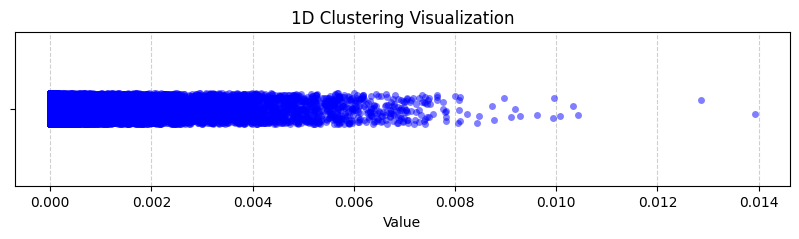

In [8]:
# the clustering at top level can "lie"
# the problem is that different locations inside the slice have different contrib ranges
# is this itself a red flag? im not sure, the thing is that there are input contribs also
# the model itself might be only interested in some other point more
# pattern coming at what contrib is not correlated for now
# each point does seem to have a contrib range where the pattern emerges

_scatter_plot_1d([item[0] for item in sms_all_pois])

In [ ]:
from collections import defaultdict
from tqdm import tqdm
coord_by_pois = defaultdict(list)
for item in tqdm(sms_all_pois):
    coord_by_pois[item[1]].append((item[0], item[2], *_get_acts_of_sm(item[2])))

 12%|█▏        | 11438/98567 [00:15<01:58, 732.96it/s]


KeyboardInterrupt: 

# (2,4)

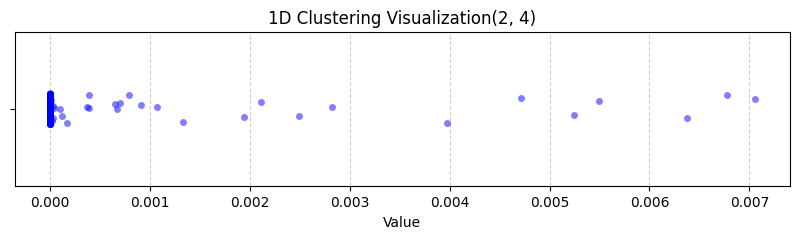

In [10]:
# quite low density
# good and easy, it might be useful to actually load everything :)
# the full dataset lol, the number of examples is quite small right now
# eh, lets still go ahead, we ll see
coord = (2, 4)
_scatter_plot_1d([item[0] for item in coord_by_pois[coord]], str(coord))

In [11]:
useful = [item for item in coord_by_pois[coord] if item[0] > 0.002]
len(useful), useful[0]

(10,
 (0.002487016376107931,
  <SaliencyMap: simple_mnist_v1/4-oVe - 4-oVe - layers.2.out_12.in_6 (saliency)>,
  <Activation: simple_mnist_v1/4-oVe - 4-oVe - x.out_0>,
  <Activation: simple_mnist_v1/4-oVe - 4-oVe - layers.0.out_6>,
  <Activation: simple_mnist_v1/4-oVe - 4-oVe - layers.2.out_12.in_6>))

# (2,3)

Im doing this cuz it has more features (although, the dataset is still too small)

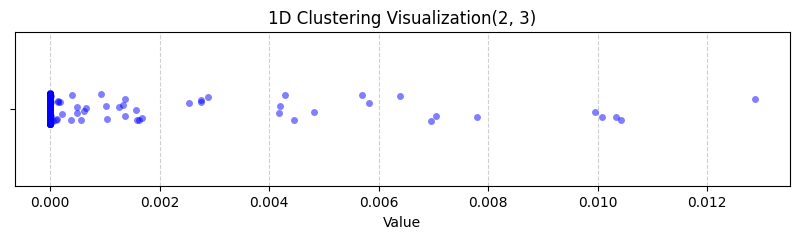

In [12]:
# quite low density
# good and easy, it might be useful to actually load everything :)
# the full dataset lol, the number of examples is quite small right now
# eh, lets still go ahead, we ll see
coord = (2, 3)
_scatter_plot_1d([item[0] for item in coord_by_pois[coord]], str(coord))

In [13]:
useful = [item for item in coord_by_pois[coord] if item[0] > 0.002]
len(useful), useful[0]

(20,
 (0.004817524459213018,
  <SaliencyMap: simple_mnist_v1/4-cYS - 4-cYS - layers.2.out_12.in_6 (saliency)>,
  <Activation: simple_mnist_v1/4-cYS - 4-cYS - x.out_0>,
  <Activation: simple_mnist_v1/4-cYS - 4-cYS - layers.0.out_6>,
  <Activation: simple_mnist_v1/4-cYS - 4-cYS - layers.2.out_12.in_6>))

In [13]:
[u[1].input.alias for u in useful]

NameError: name 'useful' is not defined

In [12]:
def useful_to_vecs():
    vecs = []
    for u in useful:
        act = np.array(u[-2].data)
        y, x = coord
        sy = y*2 - 1
        sx = x*2 - 1
        patch = act[sy:sy+3, sx:sx+3]
        vec = patch.reshape(9)
        vecs.append(vec)
    return vecs


# PCA

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
vecs = np.array(useful_to_vecs())

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(vecs)
pw = [s * kernel.reshape(9) for s in scaled_data]

X_reduced = PCA(n_components=2, whiten=True).fit_transform(pw)

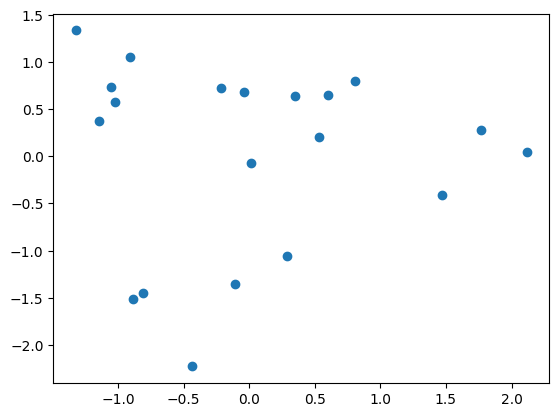

In [48]:
scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    # c=cl.labels_,
)

# Kmeans

In [18]:
from sklearn.cluster import KMeans
cl = KMeans(3, max_iter=500)
cl.fit(X_reduced)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",500
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
cl.labels_

array([0, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 1, 1, 2],
      dtype=int32)

In [21]:
l2vec = {
    0: [],
    1: [],
    2: []
}
for i, l in enumerate(cl.labels_):
    l2vec[l].append(vecs[i].reshape((3,3)))
    # print(i, l)

[<Axes: >]

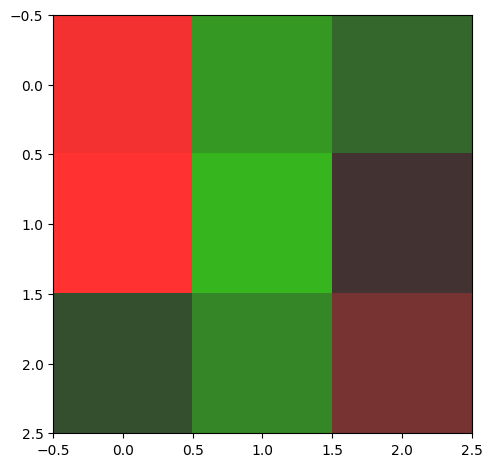

In [22]:
S([kernel])

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

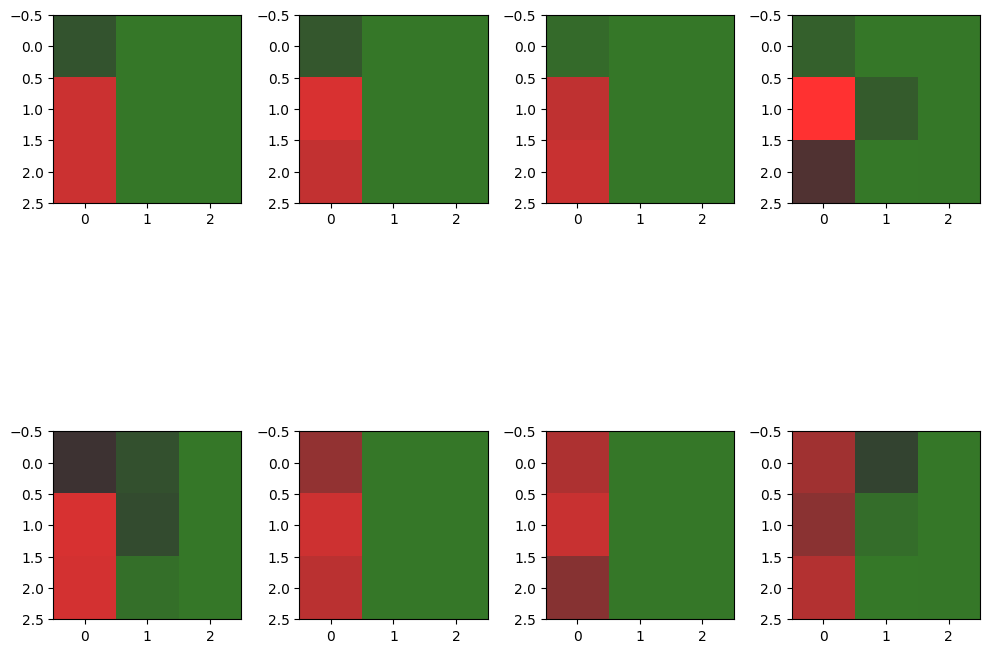

In [23]:
S(l2vec[0], ncols=4)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

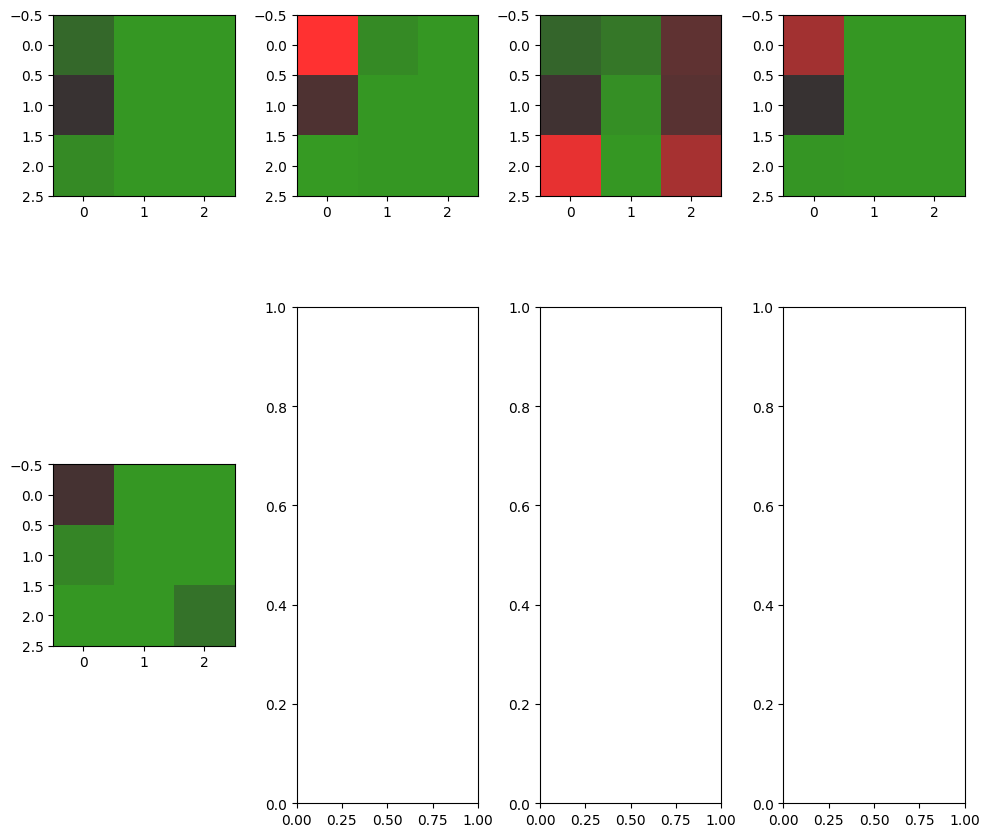

In [24]:
S(l2vec[1], ncols=4)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

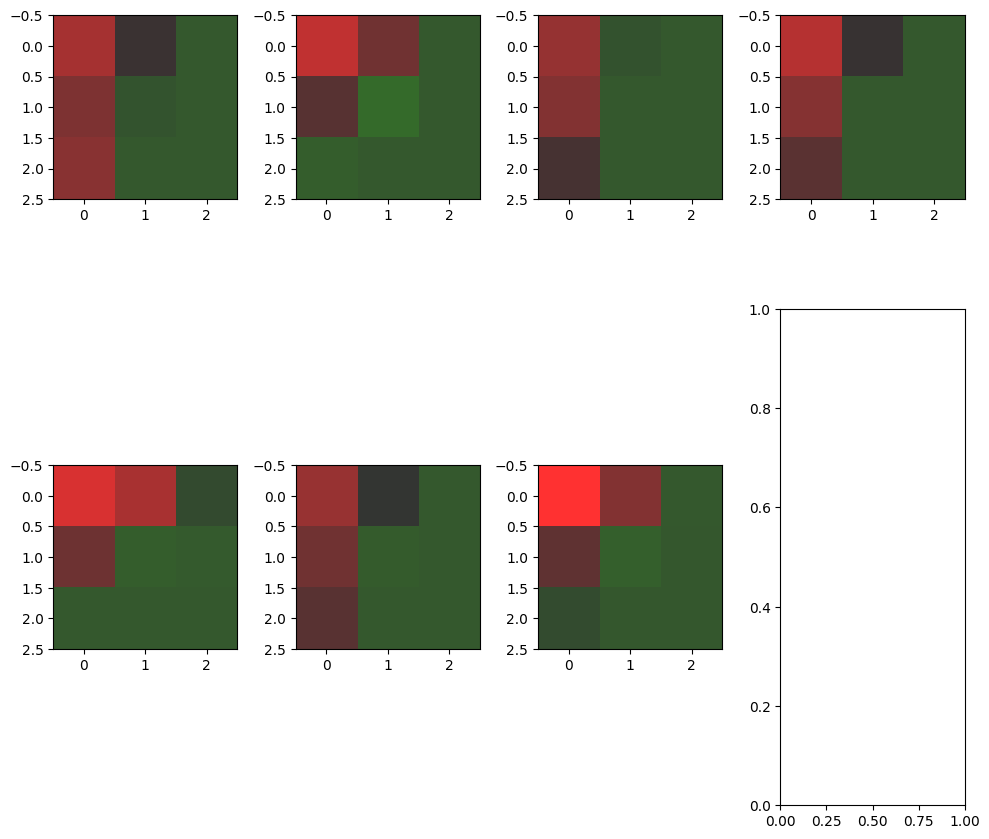

In [25]:
S(l2vec[2], ncols=4)

# Dendogram

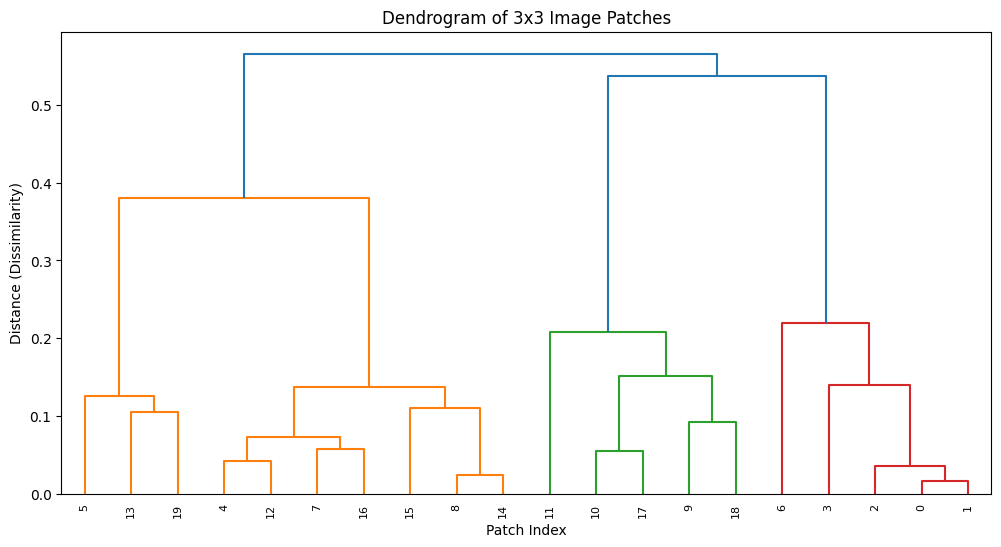

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming 'X' is your (60, 9) array of 3x3 patches
# 'ward' minimizes the variance of clusters being merged
Z = linkage(pw, method='ward')

plt.figure(figsize=(12, 6))
plt.title('Dendrogram of 3x3 Image Patches')
plt.xlabel('Patch Index')
plt.ylabel('Distance (Dissimilarity)')

# Plotting the dendrogram
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.show()

In [28]:
def _show_pws(pws, **kwargs):
    S([pw.reshape(3,3) for pw in pws], **kwargs)
    plt.show()


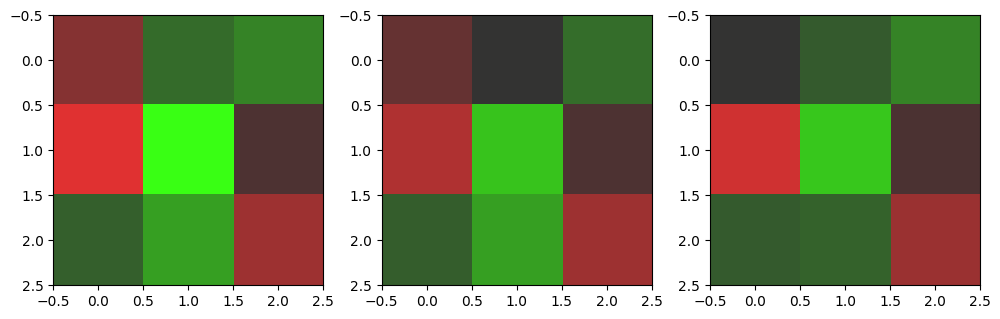

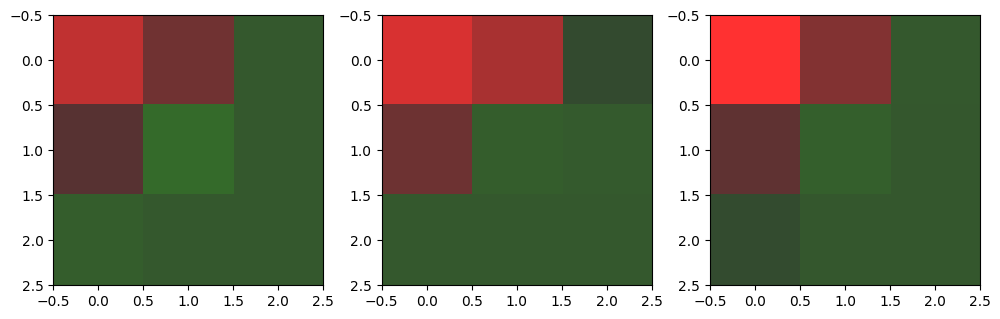

In [29]:
_show_pws([pw[5], pw[13], pw[19]], figsize=10, ncols=3)
_show_pws([vecs[5], vecs[13], vecs[19]], figsize=10, ncols=3)

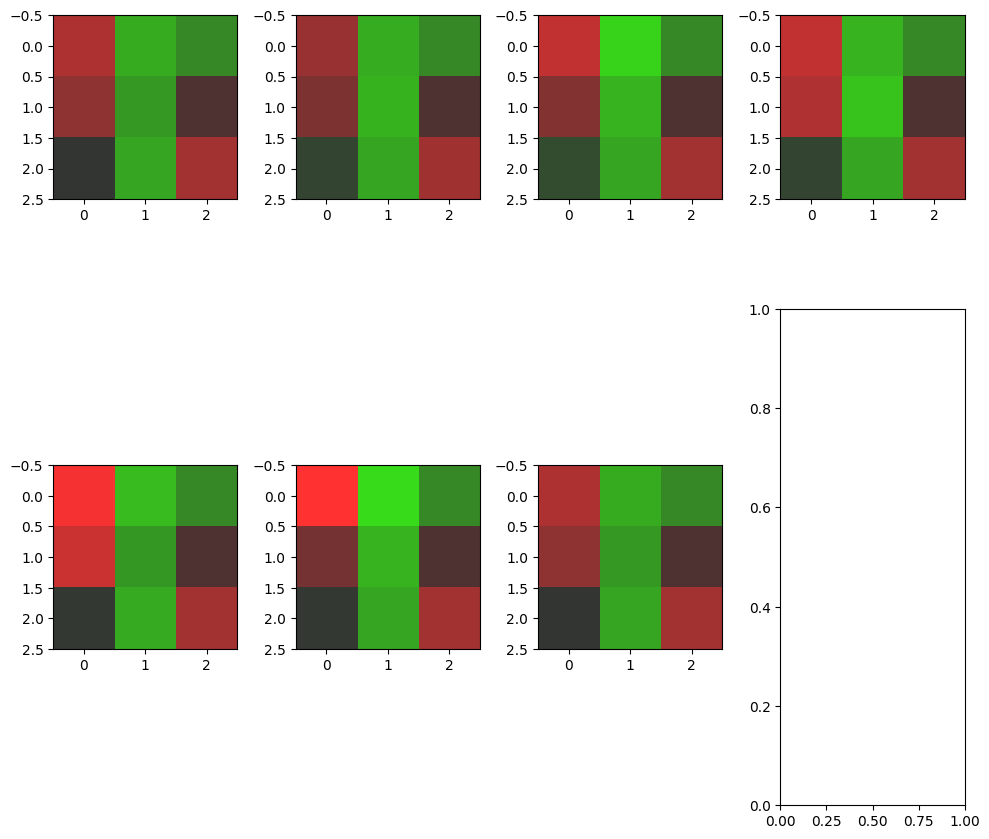

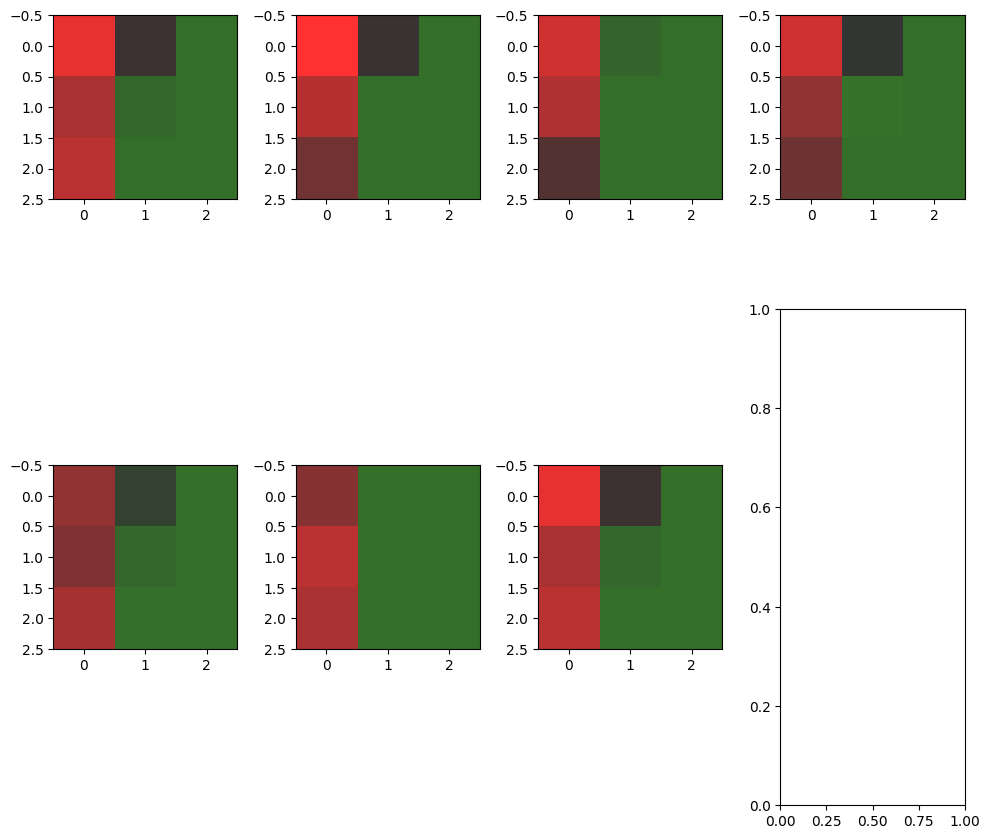

In [30]:
_show_pws([pw[4], pw[12], pw[7], pw[16], pw[15], pw[8], pw[4]], figsize=10, ncols=4)
_show_pws([vecs[4], vecs[12], vecs[7], vecs[16], vecs[15], vecs[8], vecs[4]], figsize=10, ncols=4)

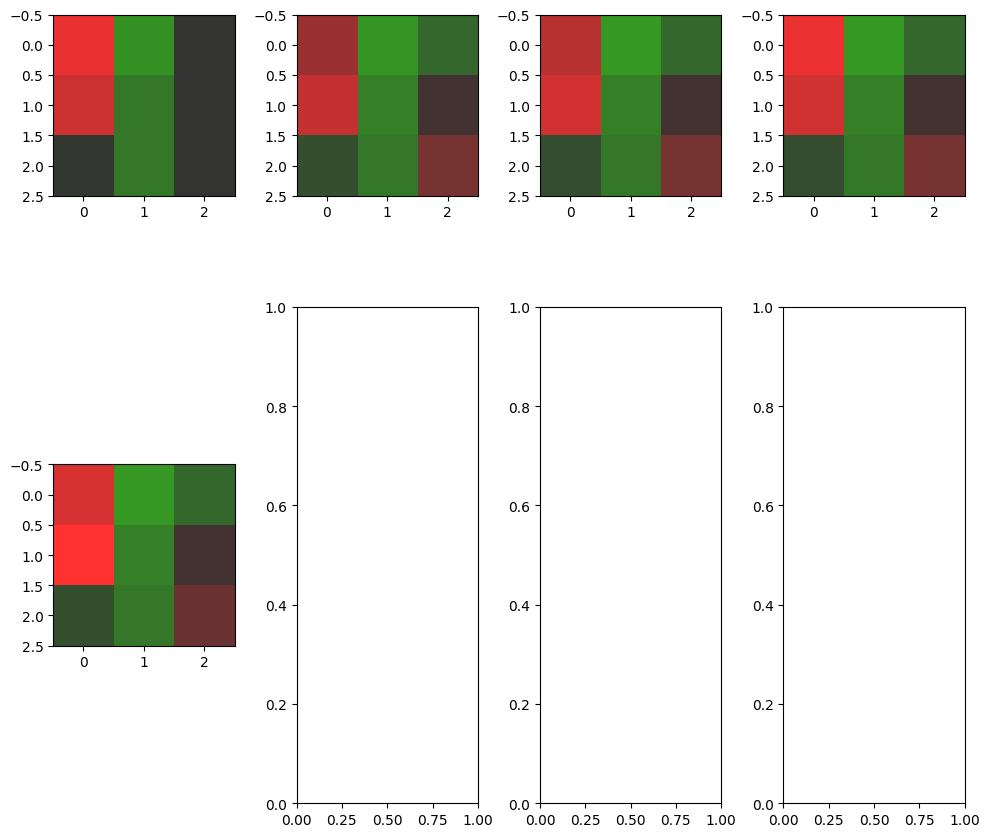

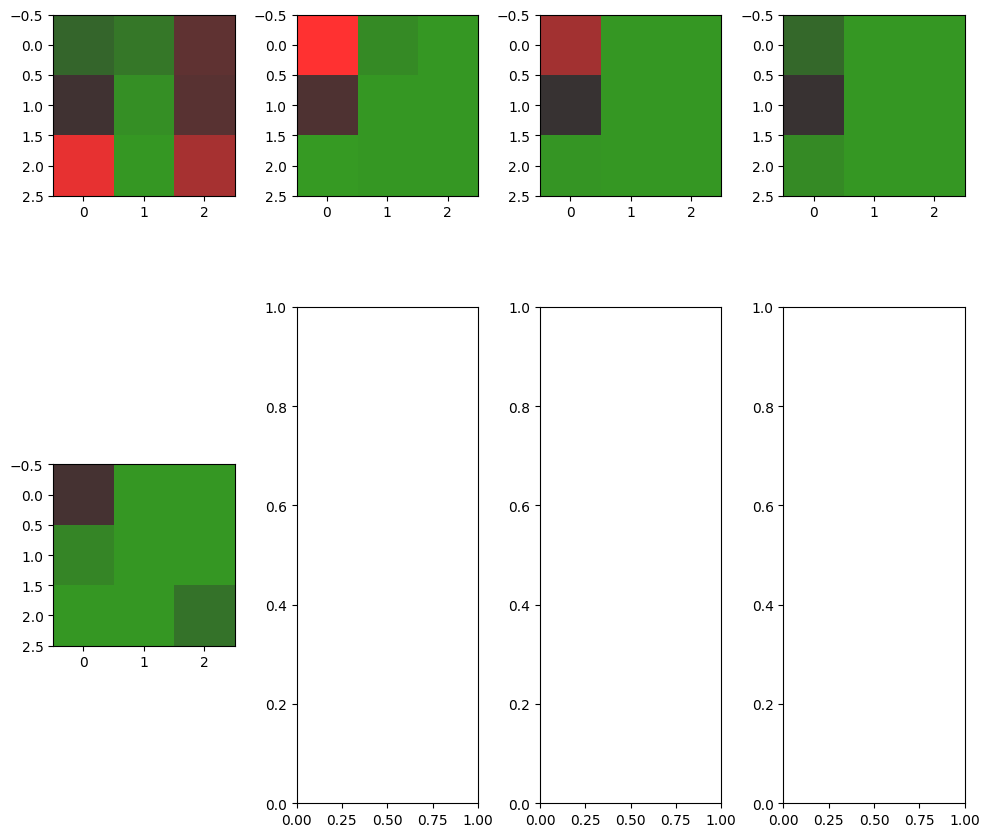

In [53]:
_show_pws([pw[11], pw[10], pw[17], pw[9], pw[18]], figsize=10, ncols=4)
_show_pws([vecs[11], vecs[10], vecs[17], vecs[9], vecs[18]], figsize=10, ncols=4)

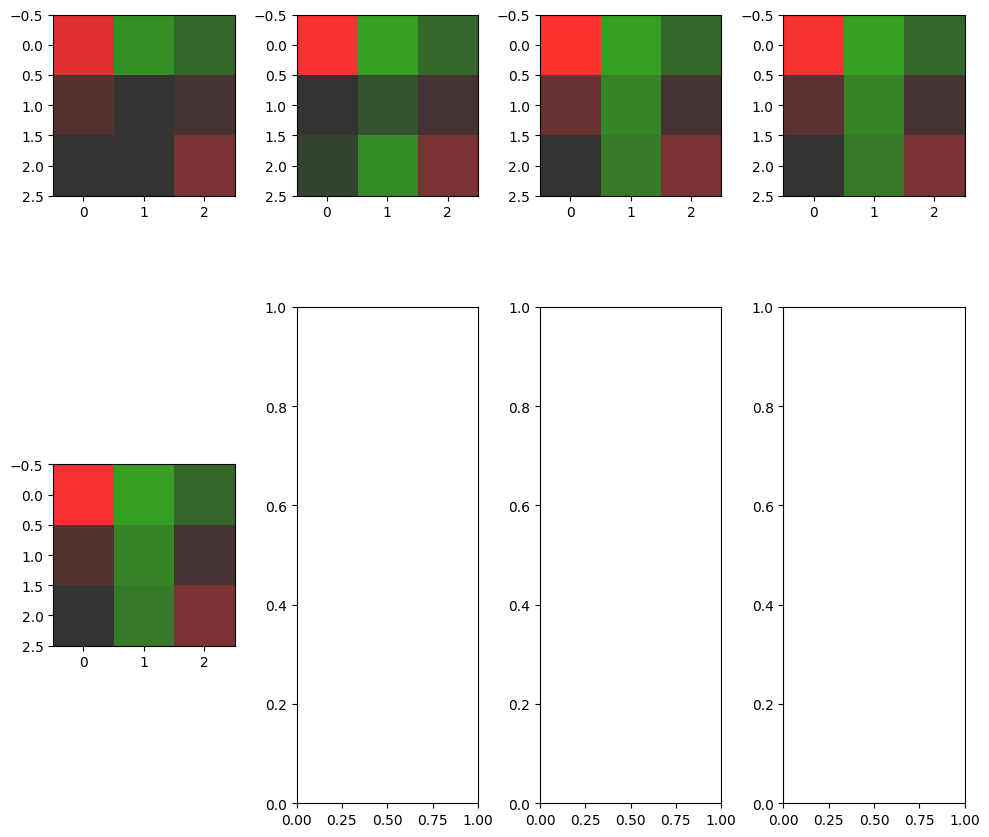

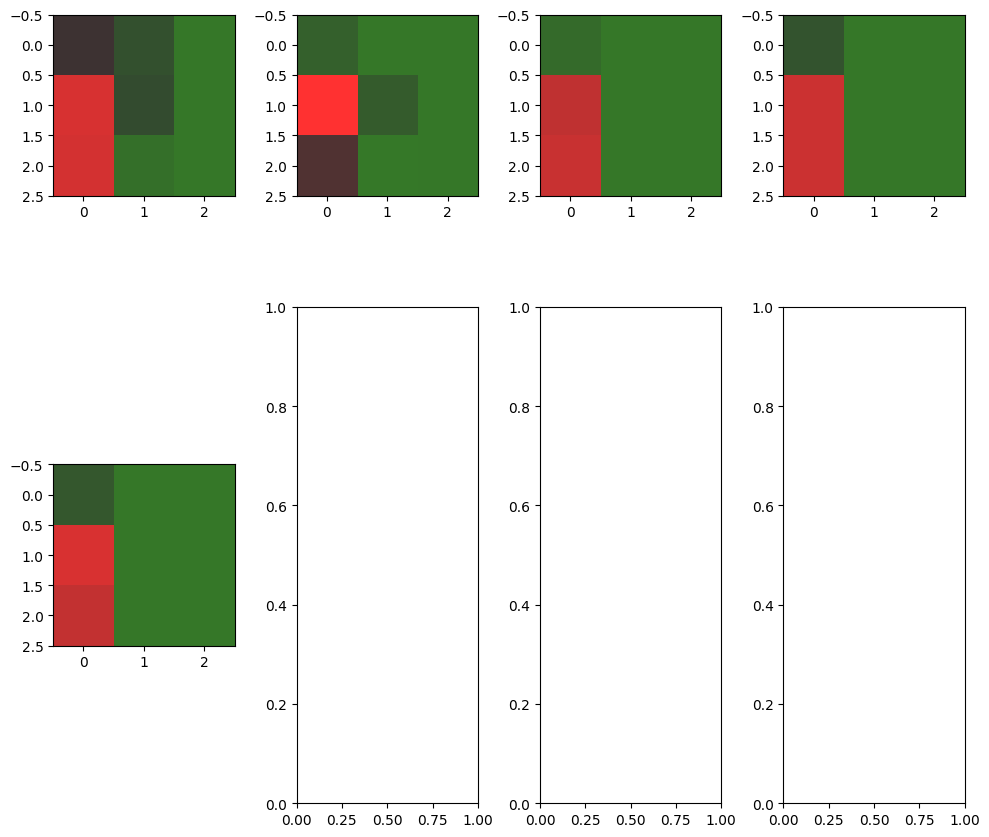

In [31]:
_show_pws([pw[6], pw[3], pw[2], pw[0], pw[1]], figsize=10, ncols=4)
_show_pws([vecs[6], vecs[3], vecs[2], vecs[0], vecs[1]], figsize=10, ncols=4)

# Agglomorative

In [292]:
from sklearn.cluster import AgglomerativeClustering

# Option A: You saw 4 clear groups in the dendrogram
clusterer = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels = clusterer.fit_predict(pw)

6# # Option B: You want to cut the tree at a specific height (distance)
# # This is great for isolating outliers! 
# # Any point further than 'distance_threshold' becomes its own group.
# clusterer = AgglomerativeClustering(n_clusters=None, distance_threshold=10.5, linkage='ward')
# labels = clusterer.fit_predict(X)

# labels will be an array like [0, 0, 1, 0, 2, 3...] 
# matching your 60 patches.

6

In [293]:
l2vs = defaultdict(list)
l2ps = defaultdict(list)

for i in range(len(pw)):
    l2vs[labels[i]].append(vecs[i].reshape(3,3))
    l2ps[labels[i]].append(pw[i].reshape(3,3))

In [294]:
l2vs.keys()

dict_keys([np.int64(2), np.int64(1), np.int64(3), np.int64(4), np.int64(0), np.int64(5)])

In [295]:
for k, v in l2vs.items():
    print(k, len(v))

2 4
1 7
3 3
4 1
0 4
5 1


In [296]:
np.stack(l2vs[2]).mean(0).shape

(3, 3)

In [297]:
def _cluster_means(l2vs):
    k_by_mean = {}
    for k in l2vs:
        k_by_mean[k] = np.stack(l2vs[k]).mean(0)
    return k_by_mean

In [303]:
label2mean = _cluster_means(l2ps)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

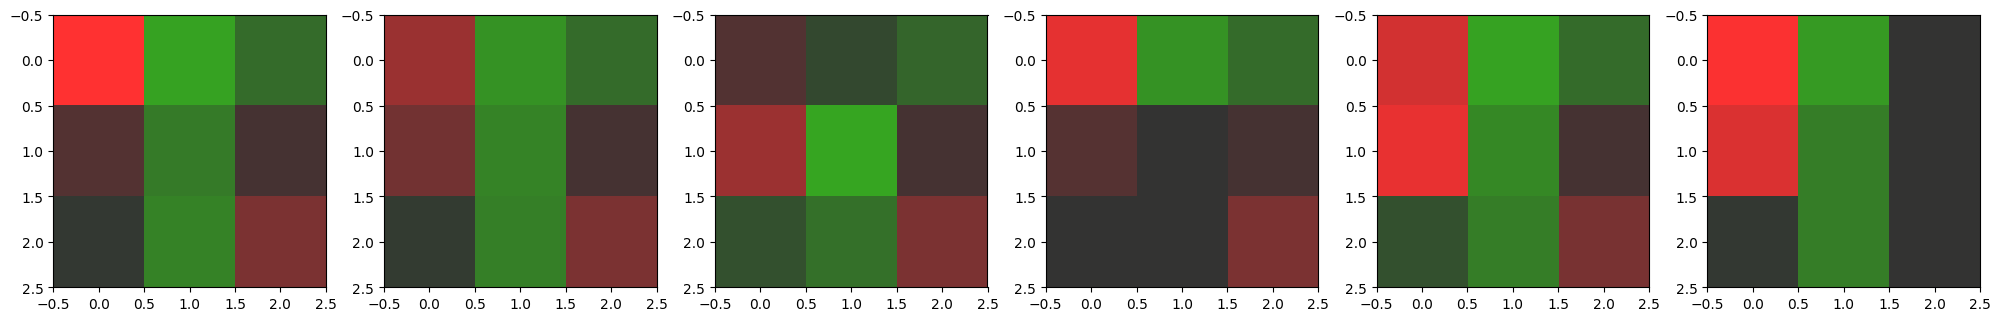

In [304]:
S([v for v in label2mean.values()], 20, ncols=6)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

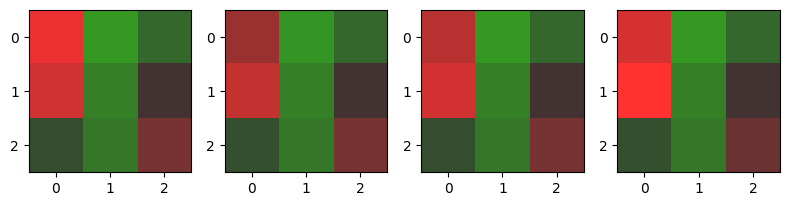

In [301]:
S(l2ps[0], 8, ncols=4)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

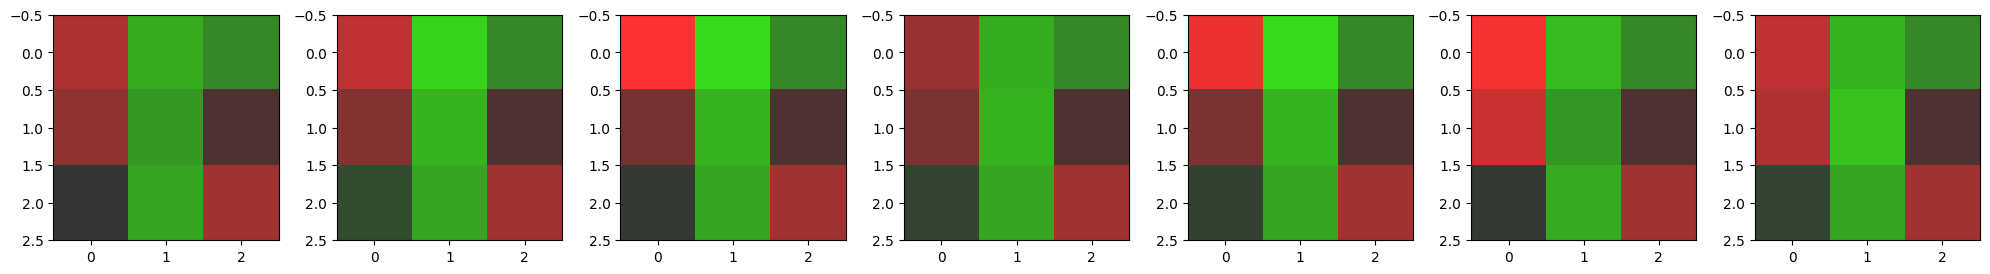

In [302]:
S(l2ps[1], 20, ncols=7)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

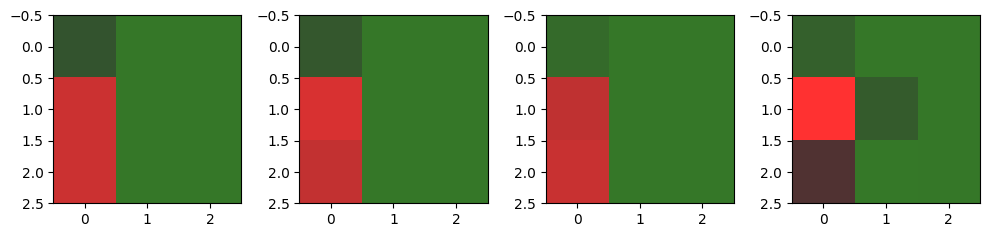

In [40]:
S(l2vs[2], 10, ncols=4)

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

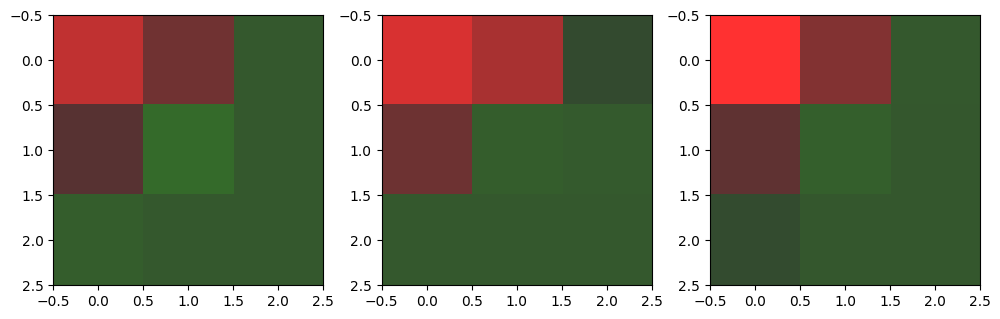

In [41]:
S(l2vs[3], 10, ncols=3)

[<Axes: >]

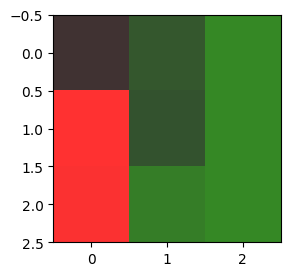

In [42]:
S(l2vs[4], 3, ncols=3)

[<Axes: >]

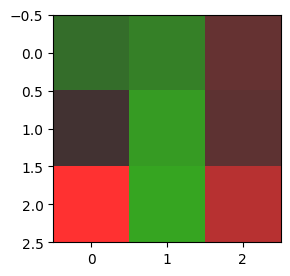

In [43]:
S(l2vs[5], 3, ncols=3)

In [44]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [45]:
sil = silhouette_score(pw, labels)
ch = calinski_harabasz_score(pw, labels)

In [46]:
sil, ch

(0.42436425119994026, 19.017099454610143)

In [47]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import pandas as pd

results = []
K_range = range(2, 11) # Checking 2 to 10 clusters
X = pw

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    
    # Calculate scores
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    results.append({'k': k, 'silhouette': sil, 'calinski': ch})

# Convert to DataFrame to find the winner
df_results = pd.DataFrame(results)
best_k = df_results.loc[df_results['silhouette'].idxmax(), 'k']
print(f"The optimal number of clusters based on Silhouette is: {best_k}")

The optimal number of clusters based on Silhouette is: 5


# Dict learning

I already have good features, now lets try dictionary learning to see if it simply takes them out :)  
Hopefully, the components it gets are basically the vectors I already have clustered.  

In [9]:
coord = (2, 3)

In [10]:
from collections import defaultdict
from tqdm import tqdm
coord_by_pois = defaultdict(list)
for item in tqdm(sms_all_pois):
    if item[1] == coord:
        coord_by_pois[item[1]].append((item[0], item[2], *_get_acts_of_sm(item[2])))

100%|██████████| 188821/188821 [00:10<00:00, 17580.37it/s]


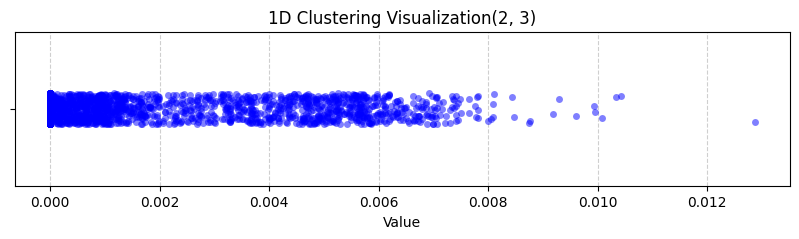

In [11]:
_scatter_plot_1d([item[0] for item in coord_by_pois[coord]], str(coord))

In [39]:
useful_gt_002 = [item for item in coord_by_pois[coord] if item[0] > 0.002]
useful = [item for item in coord_by_pois[coord]]


def useful_to_vecs(useful, coord):
    vecs = []
    for u in useful:
        act = np.array(u[-2].data)
        y, x = coord
        sy = y*2 - 1
        sx = x*2 - 1
        patch = act[sy:sy+3, sx:sx+3]
        vec = patch.reshape(9)
        vecs.append(vec)
    return vecs

vecs = useful_to_vecs(useful, coord)
vecs_002 = useful_to_vecs(useful_gt_002, coord)

len(useful), useful[0], vecs[0], vecs_002[0], len(vecs_002), len(vecs)


(4144,
 (4.960832811207183e-08,
  <SaliencyMap: simple_mnist_v1/4-aYD - 4-aYD - layers.2.out_12.in_6 (saliency)>,
  <Activation: simple_mnist_v1/4-aYD - 4-aYD - x.out_0>,
  <Activation: simple_mnist_v1/4-aYD - 4-aYD - layers.0.out_6>,
  <Activation: simple_mnist_v1/4-aYD - 4-aYD - layers.2.out_12.in_6>),
 array([ 0.07067244, -2.11318374, -1.80531418, -0.85715187, -3.38144493,
        -1.70280743, -1.29106152, -3.28134084, -1.01526904]),
 array([ 0.38279873,  0.78221774,  0.78221774, -1.74573946,  0.78221774,
         0.78221774, -1.74923646,  0.78221774,  0.78221774]),
 736,
 4144)

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

vecs = np.array(vecs)
pw = [s * kernel.reshape(9) for s in vecs]

vecs_002 = np.array(vecs_002)
pw_002 = [s * kernel.reshape(9) for s in vecs_002]

In [42]:
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.preprocessing import Normalizer

def _do_dict_learn(inputs, n_components, **kwargs):
    X = Normalizer("max").fit_transform(inputs)

    kwargs = {
        "alpha": 1,
        "max_iter": 1000,
        **kwargs,
    }
    # Learn the dictionary
    dl = MiniBatchDictionaryLearning(
        n_components=n_components, **kwargs
    )

    dl.fit(X)

    sparse_codes = dl.transform(X)
    sparse_codes
    return dl, sparse_codes, X

In [43]:
def _get_metrics(dl, sparse_codes, X):
    reconstructed = sparse_codes @ dl.components_
    diff = (X - reconstructed)
    err_sq = np.linalg.norm(diff, axis=1)

    _p = np.percentile
    metrics = {
        "l2": {
            "max": np.max(err_sq),
            "mean": np.mean(err_sq),
            "50": _p(err_sq, 50),
            "75": _p(err_sq, 75),
            "90": _p(err_sq, 90),
            "95": _p(err_sq, 95),
        },
        "err": err_sq,
    }
    return metrics

def _l2_to_df(l2_dict):
    return pd.DataFrame.from_dict({k: [v] for k,v in l2_dict.items()})

Now i need the sparsity metric also, we want to calculate:
- How many components does each basis contribute to.  
- for this, in the sparse matrix, for a single col, simply find the number of values != 0
- now this would be a number for each vector
- Lets first just see the histogram of one of them i guess
- Ill do for 1,6,10 right now

In [44]:
def _plot_ind(arr, i, ax):
    arr = arr.copy()
    arr = arr[arr != 0]
    ax.hist(arr, bins=20)
    ax.set_title(f"Column {i}")

def _plot_sparse_codes_hist(sparse_codes, n_cols):
    n_rows = int(np.ceil(sparse_codes.shape[1] / n_cols))

    _, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    for i, ax in enumerate(axes.flatten()):
        if i >= sparse_codes.shape[1]:
            break
        _plot_ind(sparse_codes[:, i], i, ax)

    plt.tight_layout()
    plt.show()

In [45]:
# we have a problem, if one of the metrics is none, we dont wanna like go weird

from sklearn.metrics import pairwise_distances
class UselessDimensionException(Exception):
    pass

def _non_zero_ratio(arr):
    return len(arr[arr != 0]) / len(arr)

def _single_dim_metrics(sparse_codes, i):
    col = sparse_codes[:, i]
    # now how much of the input the sparse code accounts for
    # that would be, for each row
    # where the current index is non zero
    # we divide the current index by total sum of that row
    mask = col != 0
    contribs = sparse_codes[mask, i] / sparse_codes[mask].sum(axis=1)
    if len(contribs) == 0:
        raise UselessDimensionException(f"contribs were empty, this dimension was not used at all for {i}")

    _p = np.percentile

    return {
        "non_zero": _non_zero_ratio(col),
        "max": np.max(contribs),
        "mean": np.mean(contribs),
        "50": _p(contribs, 50),
        "75": _p(contribs, 75),
        "90": _p(contribs, 90),
        "95": _p(contribs, 95),
    }
    

def _get_sparse_metrics(sparse_codes):
    # first, the percentage of rows it actually accounts for
    # for each index we would have this
    # i get one metric per dimension now actually, ill have to plot a bar chart for every run
    # for every dim lol
    metrics = {
        "non_zero": [],
        "max": [], 
        "mean": [], 
        "50": [], 
        "75": [], 
        "90": [], 
        "95": [], 
    }
    for i in range(sparse_codes.shape[1]):
        m = _single_dim_metrics(sparse_codes, i)
        for (k, v) in m.items():
            if k not in metrics:
                raise Exception(f"key {k} not in metrics")
            metrics[k].append(v)
    return {k: np.array(v) for k, v in metrics.items()}

def plot_error_metrics(l2_dicts):
    df = pd.DataFrame.from_dict(l2_dicts, orient="index")
    metrics = ["max", "mean", "50", "75", "90", "95"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    for ax, metric in zip(axes.flatten(), metrics):
        ax.plot(df.index, df[metric])
        ax.set_title(metric)
    plt.tight_layout()
    plt.show()

def get_similarities(dl):
    # again, we would need to show a bar chart lol
    similarity = cosine_similarity(dl.components_)
    np.fill_diagonal(similarity, -np.inf)
    return similarity.max(axis=1)


In [46]:
# import matplotlib.pyplot as plt
# import numpy as np

def plot_non_zero_bars(data, num_cols):
    metric = 'non_zero'
    keys = sorted(data.keys())
    n = len(keys)
    num_rows = (n + num_cols - 1) // num_cols
    fig_width = num_cols * 3.5
    fig_height = num_rows * 3
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))
    axes = np.array(axes).flatten()  # works for both 1D and 2D
    
    for i, key in enumerate(keys):
        ax = axes[i]
        values = data[key][metric]
        x = np.arange(len(values))
        ax.bar(x, values)
        ax.set_title(f'key={key}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'[{j}]' for j in x])
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(metric)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'"{metric}" per key', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_abnormal_metrics(data, num_cols):
    exclude = {'non_zero'}
    
    # Collect all abnormal (key, metric, values) tuples
    abnormal = []
    for key in sorted(data.keys()):
        for metric, values in data[key].items():
            if metric in exclude:
                continue
            if not np.all(values == 1.0):
                abnormal.append((key, metric, values))
    
    if not abnormal:
        print("No abnormal metrics found.")
        return
    
    n = len(abnormal)
    num_rows = (n + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3.5, num_rows * 3))
    axes = np.array(axes).flatten()
    
    for i, (key, metric, values) in enumerate(abnormal):
        ax = axes[i]
        x = np.arange(len(values))
        ax.bar(x, values)
        ax.set_title(f'key={key}  |  {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'[{j}]' for j in x])
        ax.set_ylabel(metric)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Abnormal metrics', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_similarity_bars(data, ncols=3):
    # this is not helping 
    valid = {k: v for k, v in data.items() if len(v) > 1}
    skipped = {k: v for k, v in data.items() if len(v) == 1}
    
    for k in skipped:
        print(f"Warning: key {k} has only 1 element, skipping.")

    n = len(valid)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes = np.array(axes).flatten()

    for ax, (k, arr) in zip(axes, valid.items()):
        ax.bar(range(len(arr)), arr)
        ax.set_title(f"k={k}")
        ax.set_xlabel("Component")

    for ax in axes[n:]:
        ax.set_visible(False)

    axes[0].set_ylabel("Max cosine similarity")
    plt.suptitle("Max pairwise cosine similarity per component")
    plt.tight_layout()
    plt.show()

In [47]:
len(pw)

4144

 66%|██████▌   | 19/29 [00:11<00:05,  1.68it/s]

useless dimension encountered, stopping, found-at-comp=20 cause=contribs were empty, this dimension was not used at all for 1 contribs were empty, this dimension was not used at all for 1


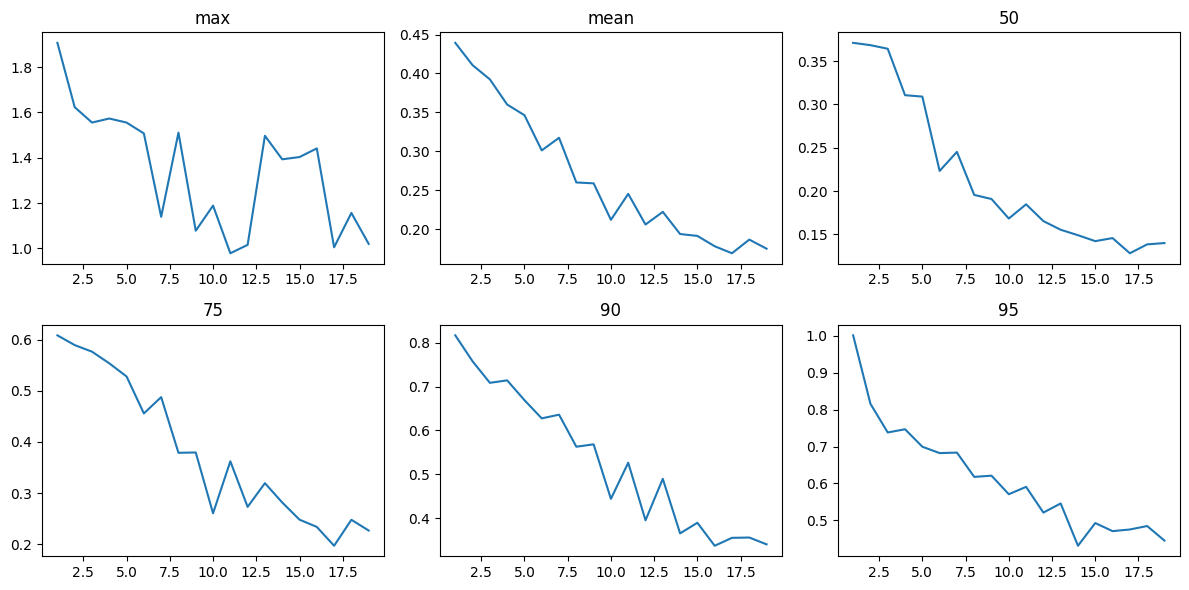

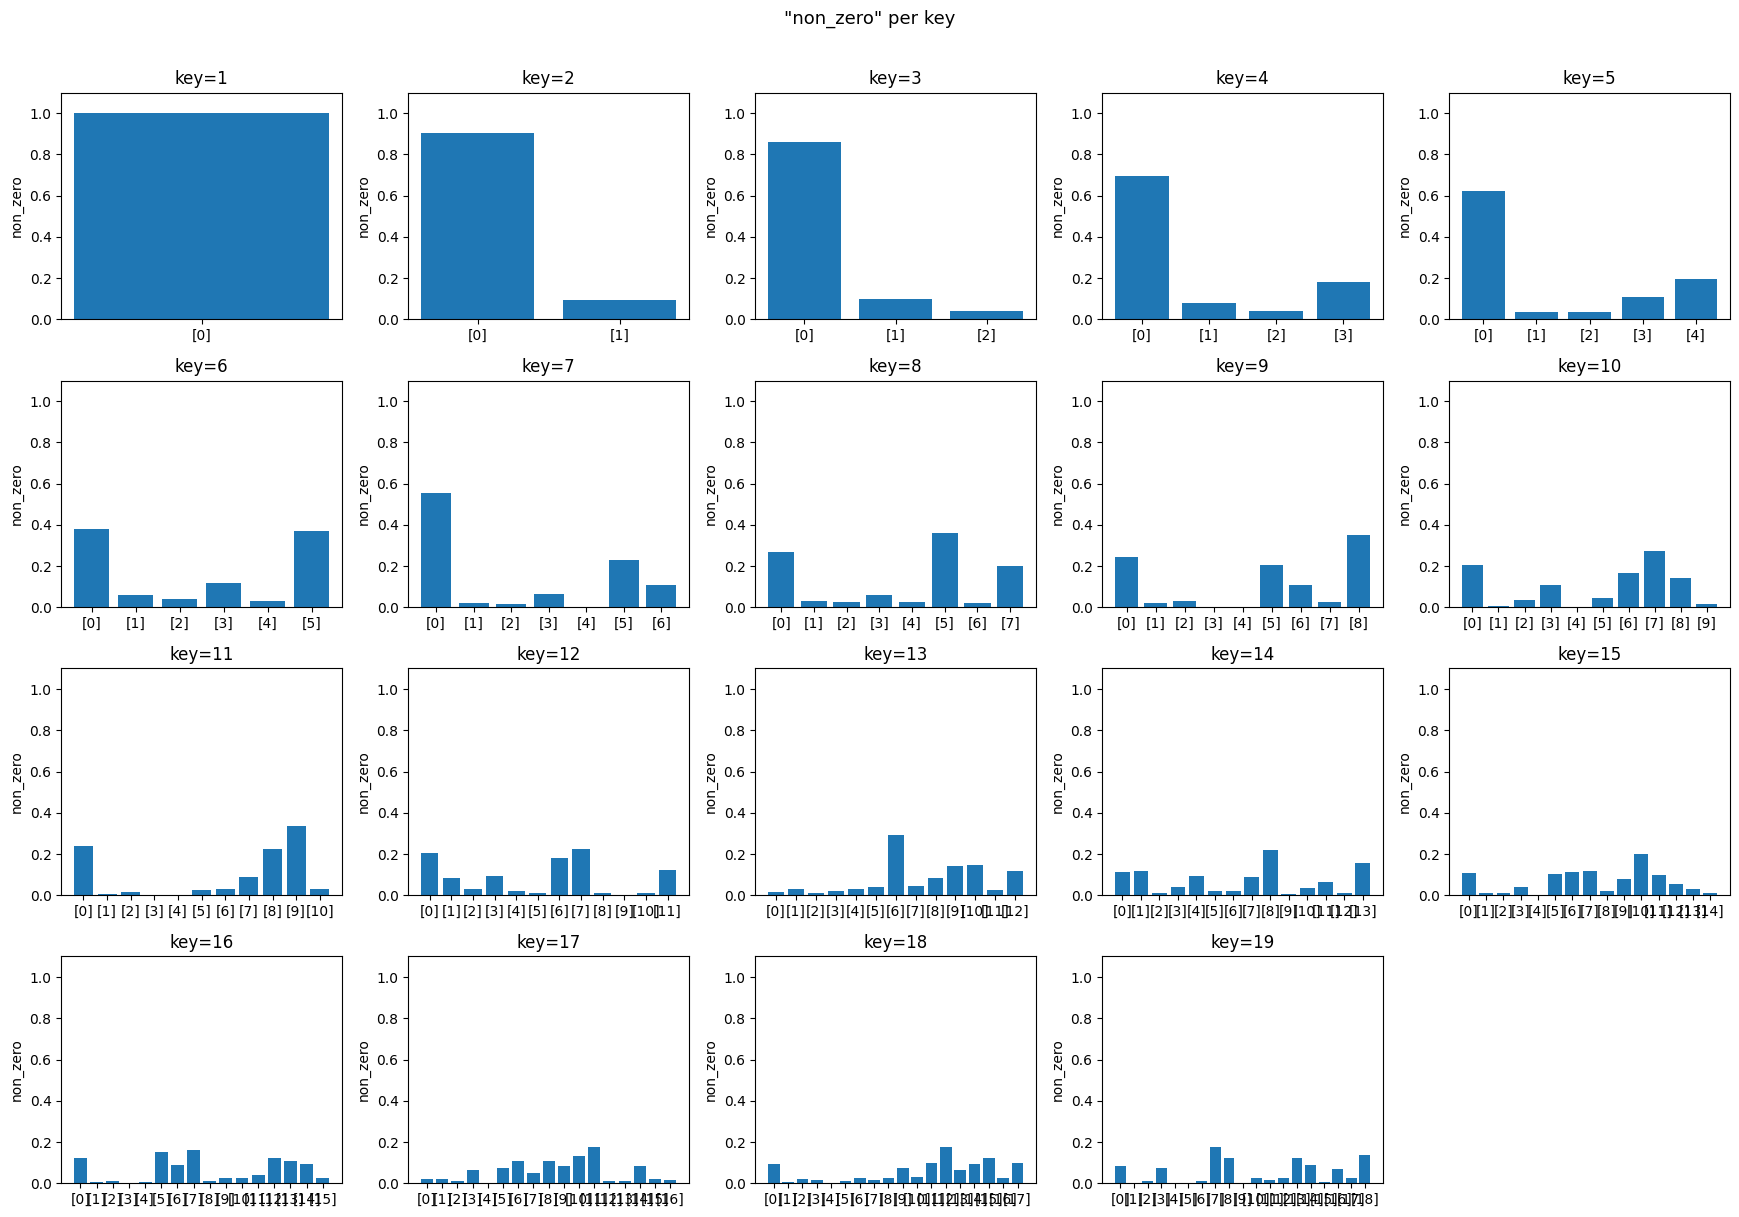

No abnormal metrics found.


In [50]:
import pandas as pd

l2_dicts = {}
sparse_dicts = {}
similarities = {}
for comp in tqdm(range(1,30)):
    dl, sparse_codes, X = _do_dict_learn(pw_002, comp)
    error_metrics = _get_metrics(dl, sparse_codes, X)
    try:
        sparse_stats = _get_sparse_metrics(sparse_codes)
    except UselessDimensionException as ex:
        print(f"useless dimension encountered, stopping, found-at-comp={comp} cause={ex}", ex)
        break
    # similarities[comp] = get_similarities(dl)
    sparse_dicts[comp] = sparse_stats
    l2_dicts[comp] = error_metrics["l2"]

plot_error_metrics(l2_dicts)
plot_non_zero_bars(sparse_dicts, 5)
plot_abnormal_metrics(sparse_dicts, 4)

 47%|████▋     | 9/19 [00:07<00:08,  1.20it/s]

useless dimension encountered, stopping, found-at-comp=10 cause=contribs were empty, this dimension was not used at all for 3 contribs were empty, this dimension was not used at all for 3


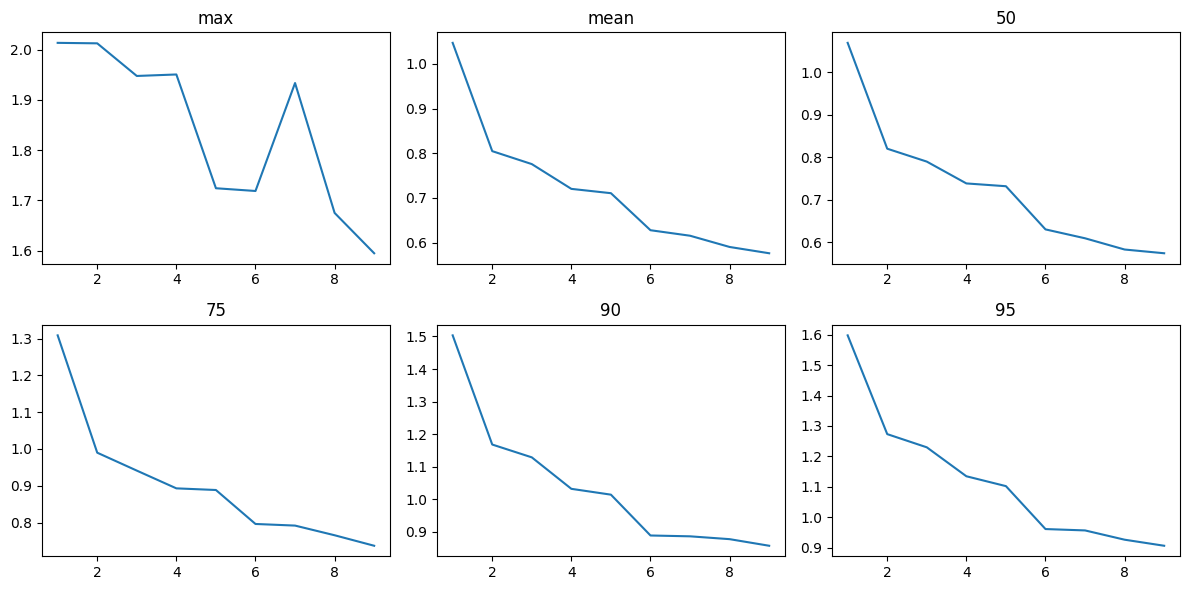

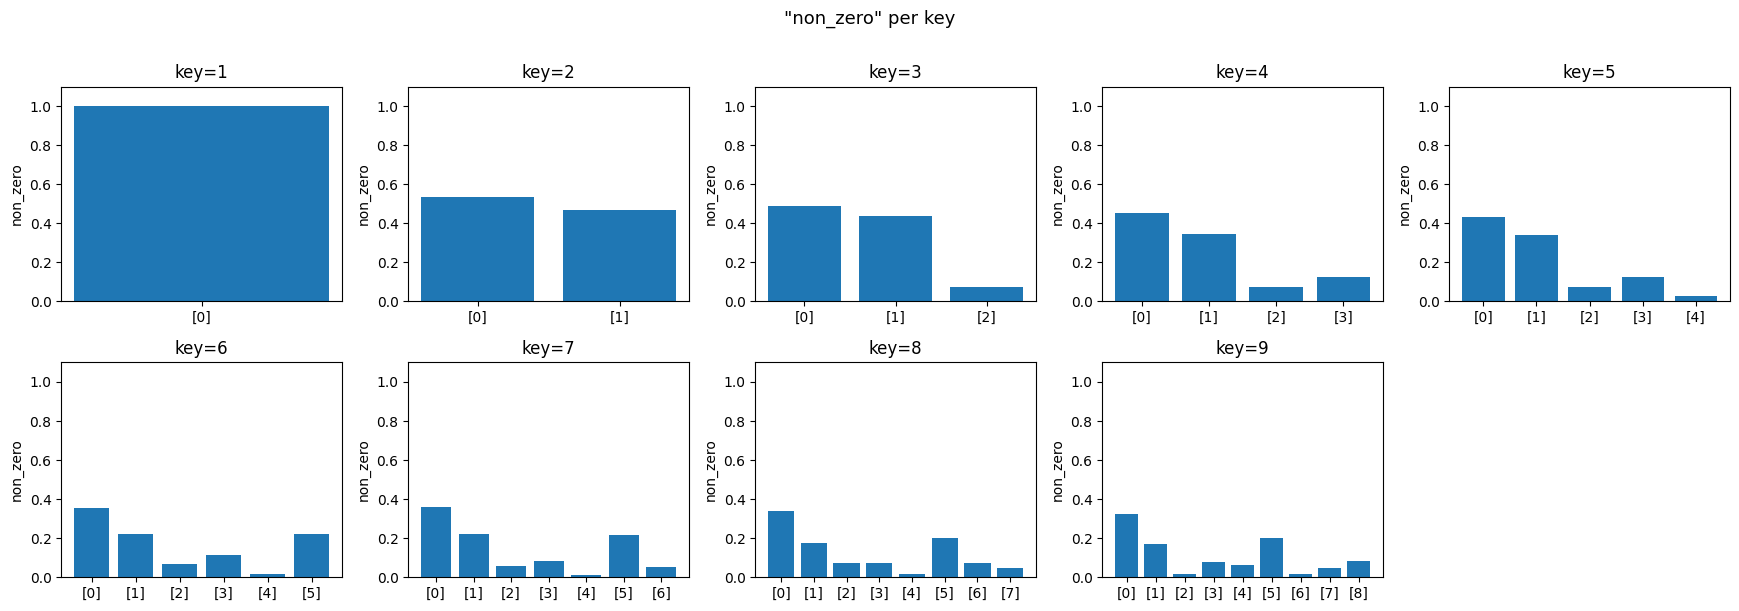

No abnormal metrics found.


In [49]:
import pandas as pd

l2_dicts = {}
sparse_dicts = {}
similarities = {}
for comp in tqdm(range(1,20)):
    dl, sparse_codes, X = _do_dict_learn(pw, comp)
    error_metrics = _get_metrics(dl, sparse_codes, X)
    try:
        sparse_stats = _get_sparse_metrics(sparse_codes)
    except UselessDimensionException as ex:
        print(f"useless dimension encountered, stopping, found-at-comp={comp} cause={ex}", ex)
        break
    # similarities[comp] = get_similarities(dl)
    sparse_dicts[comp] = sparse_stats
    l2_dicts[comp] = error_metrics["l2"]

plot_error_metrics(l2_dicts)
plot_non_zero_bars(sparse_dicts, 5)
plot_abnormal_metrics(sparse_dicts, 4)

In [ ]:
import math
def _show_dl_comps(comps, figsize, ncols):
    # nrows = math.ceil(len(comps) / ncols)
    S([c.reshape(3,3) for c in comps], )

In [ ]:
# lets do the random seed thing
# we basically find the stability of the cluster (how many are not repeating)
# we then also want to see the fraction of inputs they explain


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

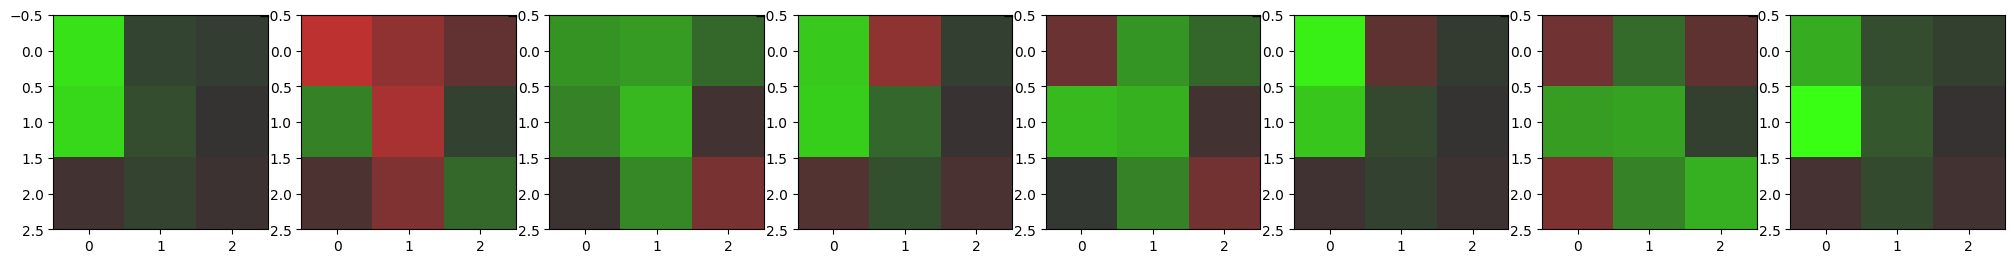

In [51]:
# it is useful to see how each looks
# i should also try clustering input patches, which have a lot more diversity
# lets try running it with different seeds, and checking the stability
# the problem right now is that i already have a very high similarity score hmmm, lets see
# they all look slightly different lol

dl, sparse_codes, X = _do_dict_learn(pw_002, 8)
S([c.reshape(3,3) for c in dl.components_], 20, len(dl.components_))

In [52]:
x_hat = sparse_codes @ dl.components_

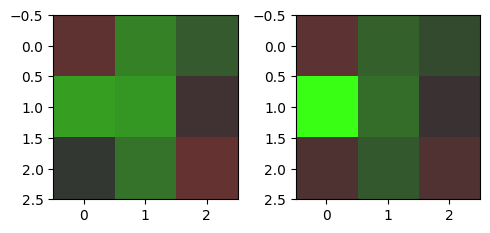

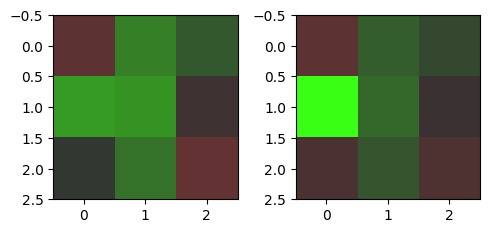

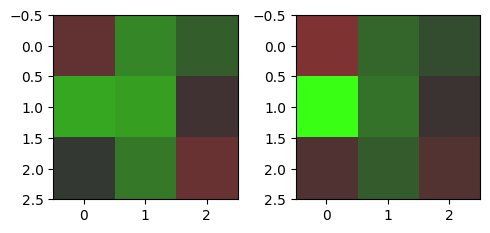

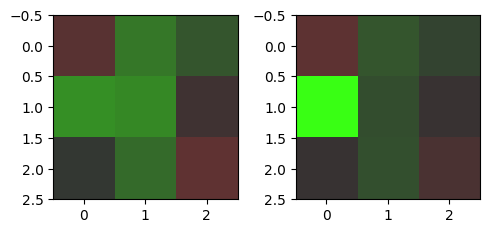

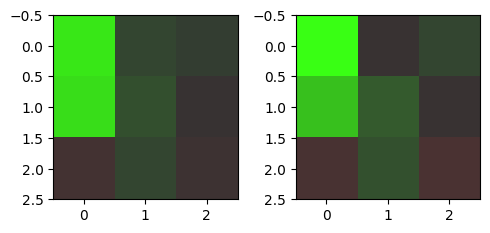

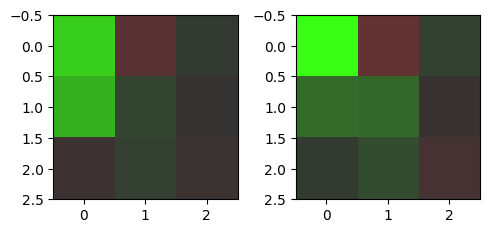

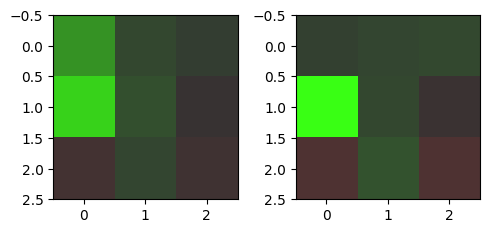

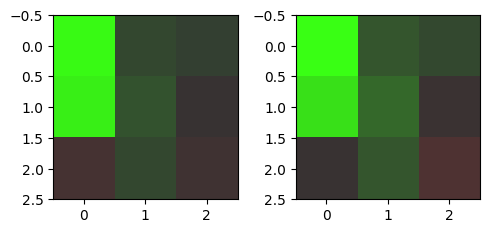

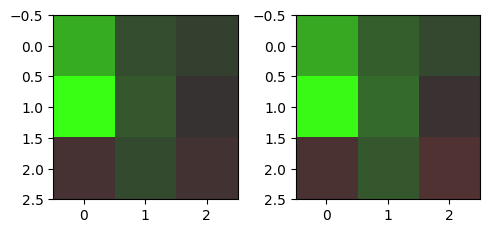

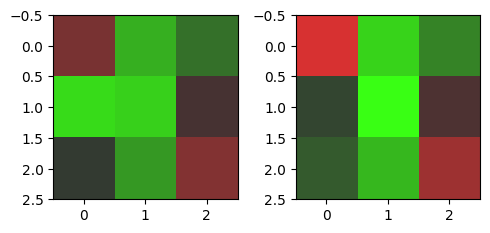

In [53]:
for i in range(10):
    S([x_hat[i].reshape(3,3), X[i].reshape(3,3)])

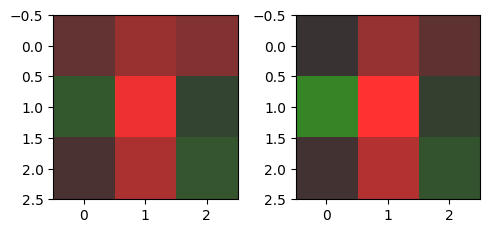

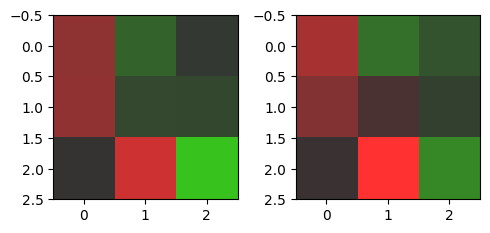

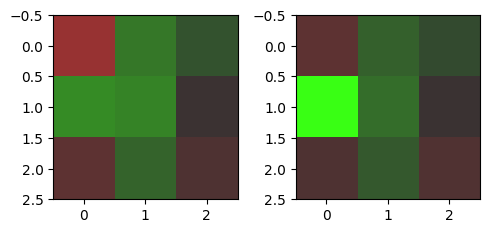

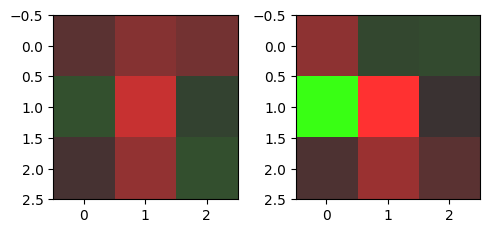

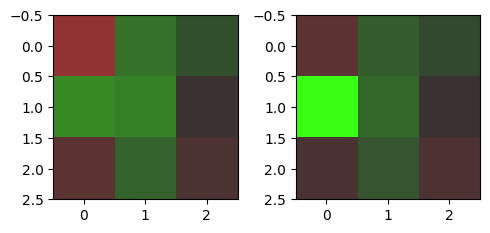

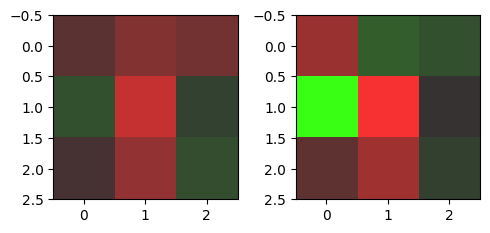

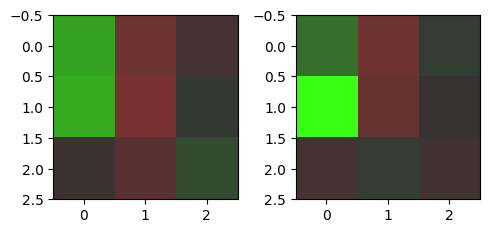

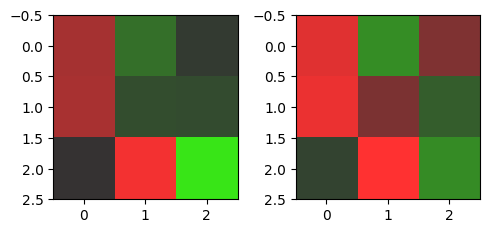

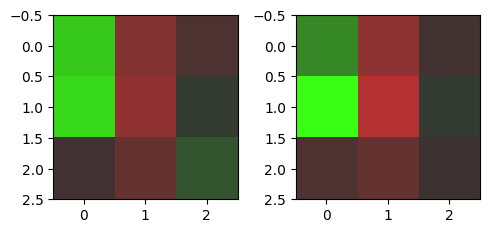

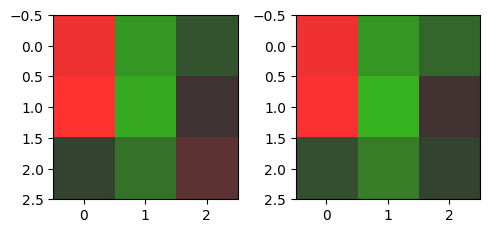

In [34]:
for i in range(10):
    S([x_hat[i].reshape(3,3), X[i].reshape(3,3)])

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

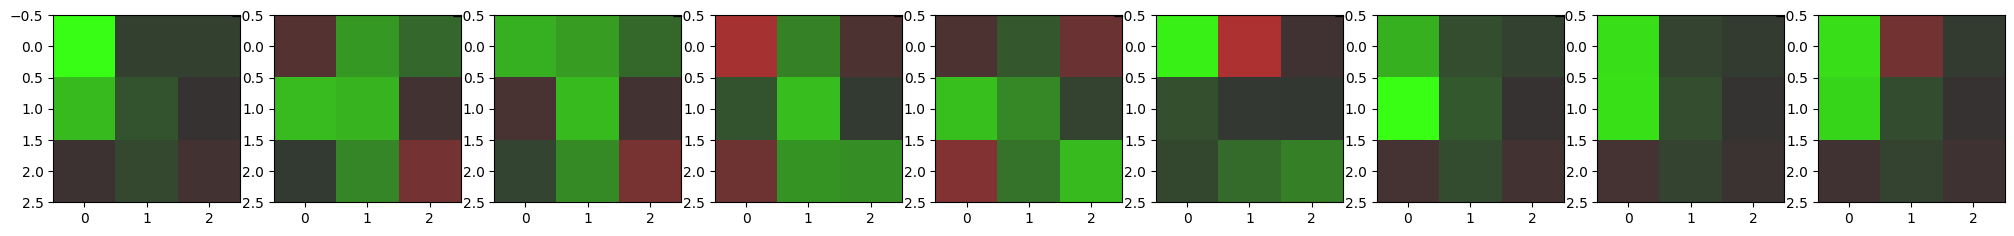

In [ ]:
dl_9, sparse_codes, X = _do_dict_learn(pw, 9)
dl.components_.shape

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

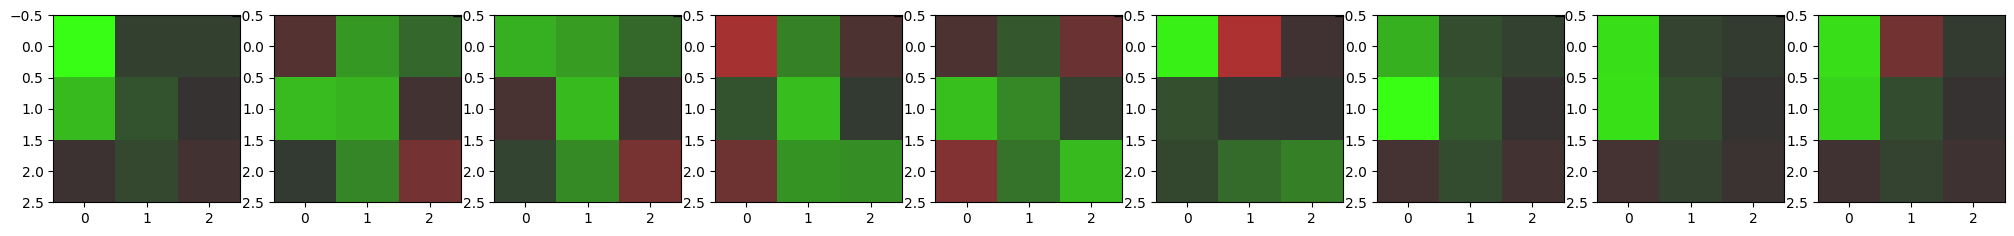

In [ ]:
# three of them are extremely similar
# and my similarity metrics are not catching it
# we do want an error term which adds provides a single number
# for each vector

# so mere paas already reconstructed input hai
# i now have the problem of not being able
# bascially, we have for each sample, the reconstruction we already have
# the model outputs a vector which is the error term
# the output is used to model the actual output
# but with one additional constraint, it should be alpha times smaller than the value already present (it would be passed as input again)
# this tries to fix the problem for us

S([c.reshape(3,3) for c in dl_9.components_], 20, len(dl_9.components_))

In [ ]:
from torch import nn

class ErrorFinderModel(nn.Module):
    def forward(self):
        pass

In [66]:
sparse_codes[4]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       1.22322986])

[<Axes: >]

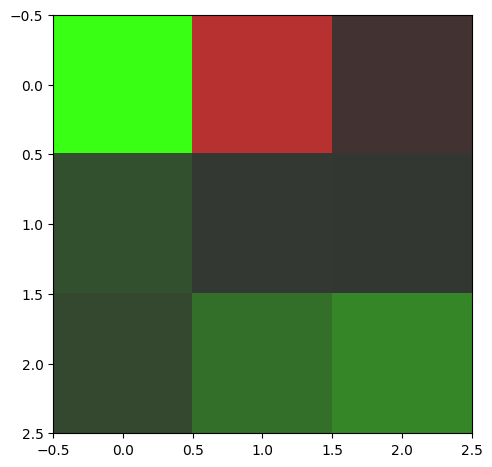

In [69]:
S([dl_9.components_[5].reshape(3,3)])

In [51]:
dl_6.components_.shape, dl_9.components_.shape

((6, 9), (9, 9))

In [79]:
from sklearn.metrics.pairwise import cosine_similarity

# similar

# cosine_similarity(dl_9.components_)
get_similarities(dl_9)
# pairwise_distances(dl_6.components_, dl_9.components_, metric="cosine").shape

array([0.97770182, 0.58658413, 0.58658413, 0.76756538, 0.76756538,
       0.72412717, 0.97166118, 0.97770182, 0.94429526])

In [166]:
# other important metrics
# cosine distance within the sparse representations (are two features redundant?)
# essentially, we track the minimum distance of a single feature with every other feature, and plot it
# technically simple, not bad
# if they are extremely similar, then maybe a small error component can take care of this (we are anyways looking at pointwise mults so it should be fine i feel)
# the problem is simple, given a set of numbers which are added (linear operation simple), find a basis vector to define the input
# in a consistent way
# small magnitude differences can be fixed using the error component.  


# stability
# we train some 10 models for the same data with different seeds
# see if the features are stable
# in this case, we find the features with minimum cosine distance to each other, and then quantify the minimum grouping
# hungarian algorithm is doing this, should be simple
# i need to see what the trend is here


# after this, it might be useful to run this on other sample datas to see how i find the correct hyperparameter

# the last approach would be to also model noise using a dense autoencoder, which penalises itself for high values
# essentially, we give it the reconstructed object
# and the original object
# it has to output a vector modelling error,we want to minimise this error vector.  
# we then have a simple reconstruction using this, and also compute how much error has accumulated across each
# for an ideal setting, the error should be small, and the main reconstruction should be big, 10x bigger than each error component atleast
# for all examples (or the majority).  
# i would also like to know about outliers though, not sure lets see.  
# this is more complicated, and i would prefer not to do it


# first we see similarity among the components
# I keep track of the minimum distance of a component from any of the other components
# the lower the distance, the worse it is for us.  

# each is a 9x1 vector, 


from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(dl.components_)

for i, sim in enumerate(similarity):
    without_us = []
    for j, s in enumerate(sim):
        if j!=i:
            without_us.append(s)
    print(i, max(without_us))


0 0.9857155050084375
1 0.9919374858194272
2 0.5972061034229305
3 0.9964193256044194
4 0.9897884357124566
5 0.992418750493817
6 0.9919374858194272
7 0.9982896471873174
8 0.9847436666408946
9 0.9848358546467765
10 0.9509249247085512
11 0.992418750493817
12 0.9857155050084375
13 0.9509249247085512
14 0.9982896471873174
15 0.9572620888720939
16 0.6543681735255868
17 0.9897884357124566
18 0.6543681735255868


In [140]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import DictionaryLearning


# ── Dictionary learning (yours, unchanged) ────────────────────────────────────

# def _do_dict_learn(inputs, n_components, **kwargs):
#     X = Normalizer("max").fit_transform(inputs)
#     kwargs = {
#         "alpha": 1,
#         "max_iter": 1000,
#         **kwargs,
#     }
#     dl = DictionaryLearning(n_components=n_components, **kwargs)
#     dl.fit(X)
#     sparse_codes = dl.transform(X)
#     return dl, sparse_codes, X


# ── Linear error model ─────────────────────────────────────────────────────────

class LinearErrorModel(nn.Module):
    """
    Learns a linear correction W such that:
        x ≈ x_hat + W @ epsilon
    with the constraint that ||W @ epsilon|| << ||x_hat||  (controlled by alpha)
    """
    def __init__(self, d: int):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)
        nn.init.zeros_(self.W.weight)   # start from no correction

    def forward(self, epsilon: torch.Tensor) -> torch.Tensor:
        return self.W(epsilon)

class NonLinearErrorModel(nn.Module):
    def __init__(self, d: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d),
        )
        # initialise last layer near zero so we start from no correction
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, epsilon: torch.Tensor) -> torch.Tensor:
        return self.net(epsilon)

def error_model_loss(
    correction: torch.Tensor,   # W @ epsilon,  shape (N, d)
    epsilon: torch.Tensor,      # residual,     shape (N, d)
    x_hat: torch.Tensor,        # reconstruction, shape (N, d)
    alpha: float,               # scale hyperparameter
    lambda_: float,             # penalty weight
) -> tuple[torch.Tensor, dict]:
    """
    Loss = MSE(correction, epsilon)
         + lambda * mean( relu(||correction|| - alpha * ||x_hat||)^2 )

    Returns (loss, dict of individual terms for logging).
    """
    # how well does the correction explain the residual?
    recon_loss = F.mse_loss(correction, epsilon)

    # scale constraint: correction should be <= alpha * x_hat in norm
    correction_norms = correction.norm(dim=1)           # (N,)
    x_hat_norms      = x_hat.norm(dim=1)                # (N,)
    scale_violation  = F.relu(correction_norms - alpha * x_hat_norms) ** 2
    scale_loss       = scale_violation.mean()

    loss = recon_loss + lambda_ * scale_loss

    return loss, {
        "recon_loss":  recon_loss.item(),
        "scale_loss":  scale_loss.item(),
        "total_loss":  loss.item(),
    }


# ── Training ───────────────────────────────────────────────────────────────────

def train_error_model(
    dl,                         # fitted DictionaryLearning object
    sparse_codes: np.ndarray,   # shape (N, n_components)
    X: np.ndarray,              # normalised input, shape (N, d)
    alpha: float = 0.1,         # correction must be <= alpha * x_hat in norm
    lambda_: float = 1.0,       # scale penalty weight
    lr: float = 1e-3,
    n_epochs: int = 500,
    verbose: bool = True,
    log_every: int = 50,
) -> tuple[LinearErrorModel, list[dict]]:

    # ── build tensors ──────────────────────────────────────────────────────────
    x_hat_np = sparse_codes @ dl.components_          # (N, d)  reconstruction
    epsilon_np = X - x_hat_np                         # (N, d)  residual

    x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
    epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

    d = X.shape[1]
    model     = NonLinearErrorModel(d, d // 2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()

        correction = model(epsilon)
        loss, terms = error_model_loss(correction, epsilon, x_hat, alpha, lambda_)

        loss.backward()
        optimizer.step()

        history.append(terms)
        if verbose and epoch % log_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"total={terms['total_loss']:.4f}  "
                f"recon={terms['recon_loss']:.4f}  "
                f"scale={terms['scale_loss']:.4f}"
            )

    return model, history


# ── Evaluation ─────────────────────────────────────────────────────────────────

def get_final_reconstruction_loss(
    model: LinearErrorModel,
    dl,
    sparse_codes: np.ndarray,
    X: np.ndarray,
    alpha,
) -> dict:
    """
    Returns per-sample and aggregate reconstruction metrics:
        loss_base   = ||x_hat - x||^2            (plain dictionary learning)
        loss_final  = ||x_hat + correction - x||^2  (with error model)
        scale_ratio = ||correction|| / ||x_hat||  (how much the correction spent)
    """
    model.eval()
    with torch.no_grad():
        x_hat_np   = sparse_codes @ dl.components_
        epsilon_np = X - x_hat_np

        x       = torch.tensor(X,          dtype=torch.float32)
        x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
        epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

        correction = model(epsilon)
        x_final    = x_hat + correction

        loss_base  = ((x_hat  - x) ** 2).mean(dim=1)   # (N,)
        loss_final = ((x_final - x) ** 2).mean(dim=1)  # (N,)

        scale_ratio = correction.norm(dim=1) / (x_hat.norm(dim=1) + 1e-8)

    mean_scale_ratio = scale_ratio.mean().item()
    return {
        # aggregate
        "mean_loss_base":   loss_base.mean().item(),
        "mean_loss_final":  loss_final.mean().item(),
        "mean_scale_ratio": mean_scale_ratio,
        # per-sample tensors (useful for plotting)
        "per_sample_loss_base":   loss_base.numpy(),
        "per_sample_loss_final":  loss_final.numpy(),
        "per_sample_scale_ratio": scale_ratio.numpy(),
        "budget_utilisation": mean_scale_ratio / alpha,
    }


def sweep_n_components(
    inputs: np.ndarray,
    component_range: list[int],
    alpha: float = 0.1,
    lambda_: float = 1.0,
    n_epochs: int = 500,
    verbose: bool = False,
    dict_learn_kwargs=None,
) -> list[dict]:
    """
    Runs the full pipeline for each n_components value.
    Returns a list of dicts with keys: n_components, loss_base, loss_final, scale_ratio
    Use the elbow in loss_final to pick n_components.
    """
    results = []

    for n in component_range:
        print(f"\n── n_components={n} ──")
        dict_learn_kwargs = {} if dict_learn_kwargs is None else dict_learn_kwargs
        dl, sparse_codes, X = _do_dict_learn(inputs, n_components=n, **dict_learn_kwargs)
        model, _ = train_error_model(
            dl, sparse_codes, X,
            alpha=alpha, lambda_=lambda_,
            n_epochs=n_epochs, verbose=verbose,
        )
        metrics = get_final_reconstruction_loss(model, dl, sparse_codes, X, alpha)
        results.append({
            "n_components":  n,
            "loss_base":     metrics["mean_loss_base"],
            "loss_final":    metrics["mean_loss_final"],
            "scale_ratio":   metrics["mean_scale_ratio"],
            "budget_utilisation": metrics["budget_utilisation"],
        })
        print(
            f"  base loss={metrics['mean_loss_base']:.4f}  "
            f"final loss={metrics['mean_loss_final']:.4f}  "
            f"scale ratio={metrics['mean_scale_ratio']:.4f}"
            f"budget utilisation={metrics['budget_utilisation']:.4f}"
        )

    return results


# ── Quick usage example ────────────────────────────────────────────────────────

# if __name__ == "__main__":
#     import matplotlib.pyplot as plt

#     # dummy data — replace with your actual inputs
#     rng = np.random.default_rng(0)
#     inputs = rng.random((200, 64)).astype(np.float32)

#     results = sweep_n_components(
#         inputs,
#         component_range=[4, 8, 16, 32, 48, 64],
#         alpha=0.1,
#         lambda_=1.0,
#         n_epochs=300,
#         verbose=False,
#     )

#     ns          = [r["n_components"] for r in results]
#     loss_base   = [r["loss_base"]    for r in results]
#     loss_final  = [r["loss_final"]   for r in results]

#     plt.figure(figsize=(7, 4))
#     plt.plot(ns, loss_base,  "o--", label="base (dict learning only)")
#     plt.plot(ns, loss_final, "o-",  label="final (+ error model)")
#     plt.xlabel("n_components")
#     plt.ylabel("mean reconstruction loss")
#     plt.title("Elbow plot — pick n where final loss plateaus")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("elbow.png", dpi=150)
#     plt.show()

In [127]:
# import matplotlib.pyplot as plt

def plot_results(results, alpha):
    ns              = [r["n_components"]      for r in results]
    loss_base       = [r["loss_base"]         for r in results]
    loss_final      = [r["loss_final"]        for r in results]
    budget_util     = [r["scale_ratio"] / alpha for r in results]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

    # loss curves
    ax1.plot(ns, loss_base,  "o--", label="base (dict learning only)")
    ax1.plot(ns, loss_final, "o-",  label="final (+ error model)")
    ax1.set_ylabel("mean reconstruction loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # budget utilisation
    ax2.plot(ns, budget_util, "o-", color="tomato", label="budget utilisation")
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="target (≤ 1.0)")
    ax2.set_ylabel("scale_ratio / alpha")
    ax2.set_xlabel("n_components")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("elbow.png", dpi=150)
    plt.show()

In [136]:
results = sweep_n_components(pw, list(range(1,20)), 0.05, 2)


── n_components=1 ──
  base loss=0.0355  final loss=0.0287  scale ratio=0.0671budget utilisation=1.3421

── n_components=2 ──
  base loss=0.0272  final loss=0.0212  scale ratio=0.0595budget utilisation=1.1898

── n_components=3 ──
  base loss=0.0225  final loss=0.0174  scale ratio=0.0538budget utilisation=1.0768

── n_components=4 ──
  base loss=0.0213  final loss=0.0167  scale ratio=0.0533budget utilisation=1.0653

── n_components=5 ──
  base loss=0.0211  final loss=0.0161  scale ratio=0.0519budget utilisation=1.0383

── n_components=6 ──
  base loss=0.0189  final loss=0.0142  scale ratio=0.0512budget utilisation=1.0244

── n_components=7 ──
  base loss=0.0182  final loss=0.0137  scale ratio=0.0503budget utilisation=1.0065

── n_components=8 ──
  base loss=0.0119  final loss=0.0087  scale ratio=0.0419budget utilisation=0.8372

── n_components=9 ──
  base loss=0.0115  final loss=0.0086  scale ratio=0.0410budget utilisation=0.8196

── n_components=10 ──
  base loss=0.0089  final loss=0

In [135]:
results[5]

{'n_components': 6,
 'loss_base': 0.018871519714593887,
 'loss_final': 0.0111104566603899,
 'scale_ratio': 0.08965389430522919,
 'budget_utilisation': 0.8965389430522919}

In [138]:
results

[{'n_components': 1,
  'loss_base': 0.035520393401384354,
  'loss_final': 0.02866373583674431,
  'scale_ratio': 0.0671057403087616,
  'budget_utilisation': 1.342114806175232},
 {'n_components': 2,
  'loss_base': 0.027164043858647346,
  'loss_final': 0.021208636462688446,
  'scale_ratio': 0.059488631784915924,
  'budget_utilisation': 1.1897726356983185},
 {'n_components': 3,
  'loss_base': 0.022506916895508766,
  'loss_final': 0.017392465844750404,
  'scale_ratio': 0.05383964255452156,
  'budget_utilisation': 1.0767928510904312},
 {'n_components': 4,
  'loss_base': 0.021289164200425148,
  'loss_final': 0.01668567955493927,
  'scale_ratio': 0.053266946226358414,
  'budget_utilisation': 1.0653389245271683},
 {'n_components': 5,
  'loss_base': 0.021060552448034286,
  'loss_final': 0.016140691936016083,
  'scale_ratio': 0.051916856318712234,
  'budget_utilisation': 1.0383371263742447},
 {'n_components': 6,
  'loss_base': 0.01887287013232708,
  'loss_final': 0.014244032092392445,
  'scale_ra

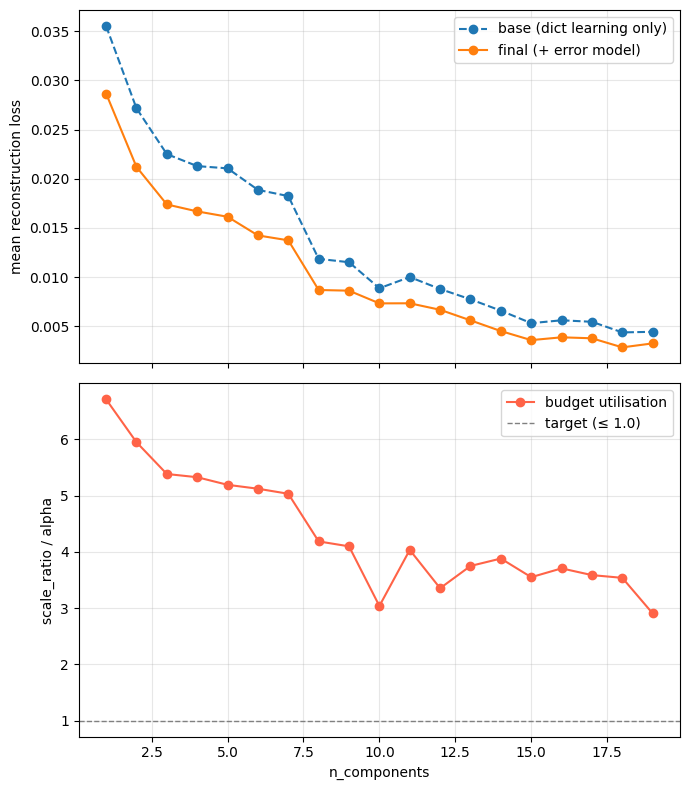

In [137]:
plot_results(results, 0.01)

In [141]:
def sweep_with_seeds(inputs, component_range, seeds, alpha=0.05, lambda_=2.0, n_epochs=500):
    all_results = {}
    
    for seed in seeds:
        print(f"\n── seed={seed} ──")
        results = sweep_n_components(
            inputs, component_range,
            alpha=alpha, lambda_=lambda_,
            n_epochs=n_epochs,
            dict_learn_kwargs={"random_state": seed},  # pass seed to DictionaryLearning
        )
        for r in results:
            n = r["n_components"]
            if n not in all_results:
                all_results[n] = {"loss_base": [], "loss_final": [], "budget_utilisation": []}
            all_results[n]["loss_base"].append(r["loss_base"])
            all_results[n]["loss_final"].append(r["loss_final"])
            all_results[n]["budget_utilisation"].append(r["scale_ratio"] / alpha)
    
    return all_results


def plot_stability(all_results, alpha):
    ns = sorted(all_results.keys())
    
    def mean_std(key):
        means = [np.mean(all_results[n][key]) for n in ns]
        stds  = [np.std(all_results[n][key])  for n in ns]
        return np.array(means), np.array(stds)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

    for key, label, color, ax in [
        ("loss_base",  "base loss",  "steelblue", ax1),
        ("loss_final", "final loss", "seagreen",  ax1),
    ]:
        means, stds = mean_std(key)
        ax.plot(ns, means, "o-", label=label, color=color)
        ax.fill_between(ns, means - stds, means + stds, alpha=0.2, color=color)

    ax1.set_ylabel("mean reconstruction loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    means, stds = mean_std("budget_utilisation")
    ax2.plot(ns, means, "o-", color="tomato", label="budget utilisation")
    ax2.fill_between(ns, means - stds, means + stds, alpha=0.2, color="tomato")
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="target (≤ 1.0)")
    ax2.set_ylabel("scale_ratio / alpha")
    ax2.set_xlabel("n_components")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("stability.png", dpi=150)
    plt.show()

In [142]:
all_results = sweep_with_seeds(pw, range(3,10), [1, 10, 40, 100, 50], alpha=0.05, lambda_=2.0, n_epochs=500)


── seed=1 ──

── n_components=3 ──
  base loss=0.0225  final loss=0.0172  scale ratio=0.0531budget utilisation=1.0626

── n_components=4 ──
  base loss=0.0213  final loss=0.0162  scale ratio=0.0535budget utilisation=1.0705

── n_components=5 ──
  base loss=0.0211  final loss=0.0159  scale ratio=0.0551budget utilisation=1.1028

── n_components=6 ──
  base loss=0.0189  final loss=0.0143  scale ratio=0.0514budget utilisation=1.0285

── n_components=7 ──
  base loss=0.0183  final loss=0.0142  scale ratio=0.0471budget utilisation=0.9429

── n_components=8 ──
  base loss=0.0135  final loss=0.0100  scale ratio=0.0451budget utilisation=0.9027

── n_components=9 ──
  base loss=0.0111  final loss=0.0083  scale ratio=0.0401budget utilisation=0.8015

── seed=10 ──

── n_components=3 ──
  base loss=0.0225  final loss=0.0171  scale ratio=0.0562budget utilisation=1.1239

── n_components=4 ──
  base loss=0.0213  final loss=0.0161  scale ratio=0.0546budget utilisation=1.0928

── n_components=5 ──
  ba

In [120]:
results

[{'n_components': 1,
  'loss_base': 0.035520393401384354,
  'loss_final': 0.028046641498804092,
  'scale_ratio': 0.06647481769323349,
  'budget_utilisation': 6.647481769323349},
 {'n_components': 2,
  'loss_base': 0.027164043858647346,
  'loss_final': 0.021288180723786354,
  'scale_ratio': 0.04987236484885216,
  'budget_utilisation': 4.987236484885216},
 {'n_components': 3,
  'loss_base': 0.022506916895508766,
  'loss_final': 0.017524054273962975,
  'scale_ratio': 0.04534583166241646,
  'budget_utilisation': 4.534583166241646},
 {'n_components': 4,
  'loss_base': 0.021289164200425148,
  'loss_final': 0.01654043421149254,
  'scale_ratio': 0.044679295271635056,
  'budget_utilisation': 4.4679295271635056},
 {'n_components': 5,
  'loss_base': 0.021060552448034286,
  'loss_final': 0.01636403240263462,
  'scale_ratio': 0.04442186653614044,
  'budget_utilisation': 4.442186653614044},
 {'n_components': 6,
  'loss_base': 0.020492063835263252,
  'loss_final': 0.015920858830213547,
  'scale_ratio

In [144]:
all_results

{3: {'loss_base': [0.022506916895508766,
   0.022506916895508766,
   0.022506916895508766,
   0.022506916895508766,
   0.022506916895508766],
  'loss_final': [0.01720144972205162,
   0.017079748213291168,
   0.017194688320159912,
   0.01788610965013504,
   0.017076438292860985],
  'budget_utilisation': [1.0625556856393814,
   1.1239493638277054,
   1.1901943385601044,
   1.050068810582161,
   1.125965416431427]},
 4: {'loss_base': [0.021289164200425148,
   0.021289164200425148,
   0.021289164200425148,
   0.021289164200425148,
   0.021289164200425148],
  'loss_final': [0.016218142583966255,
   0.016141055151820183,
   0.01625075936317444,
   0.016049383208155632,
   0.016164559870958328],
  'budget_utilisation': [1.070515587925911,
   1.0927873849868774,
   1.1101964861154556,
   1.1075180023908615,
   1.1243318766355515]},
 5: {'loss_base': [0.021060552448034286,
   0.021060552448034286,
   0.021060552448034286,
   0.021060552448034286,
   0.021060552448034286],
  'loss_final': [0.015

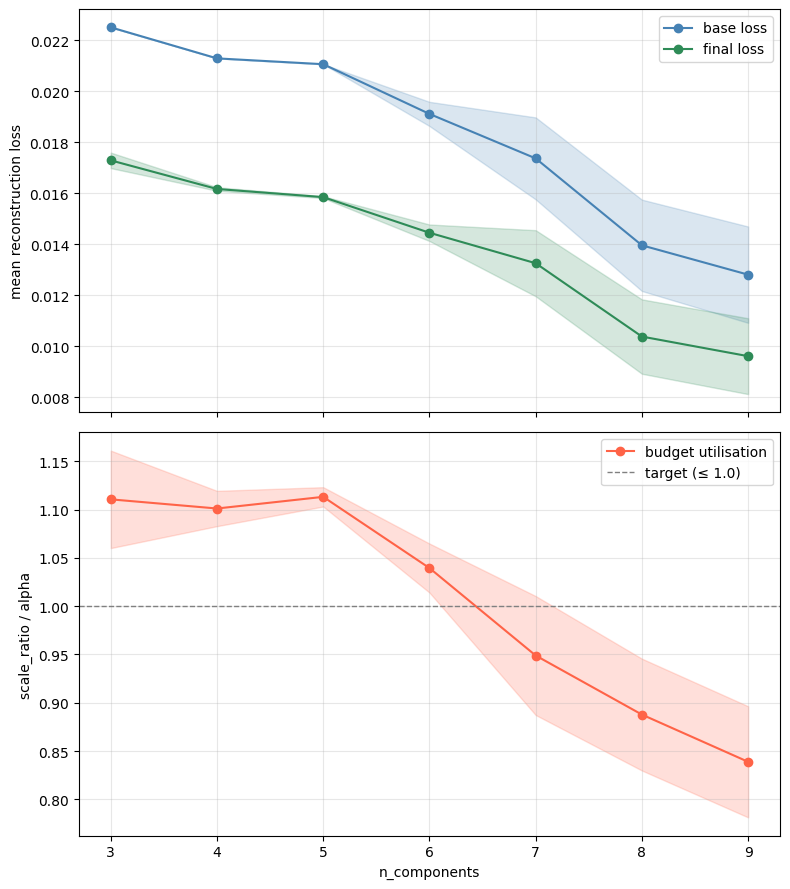

In [143]:
plot_stability(all_results, alpha=0.05)


In [150]:
dl, sparse_codes, X = _do_dict_learn(pw, 6)

In [152]:
dl, sparse_codes, X = _do_dict_learn(pw, 9)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

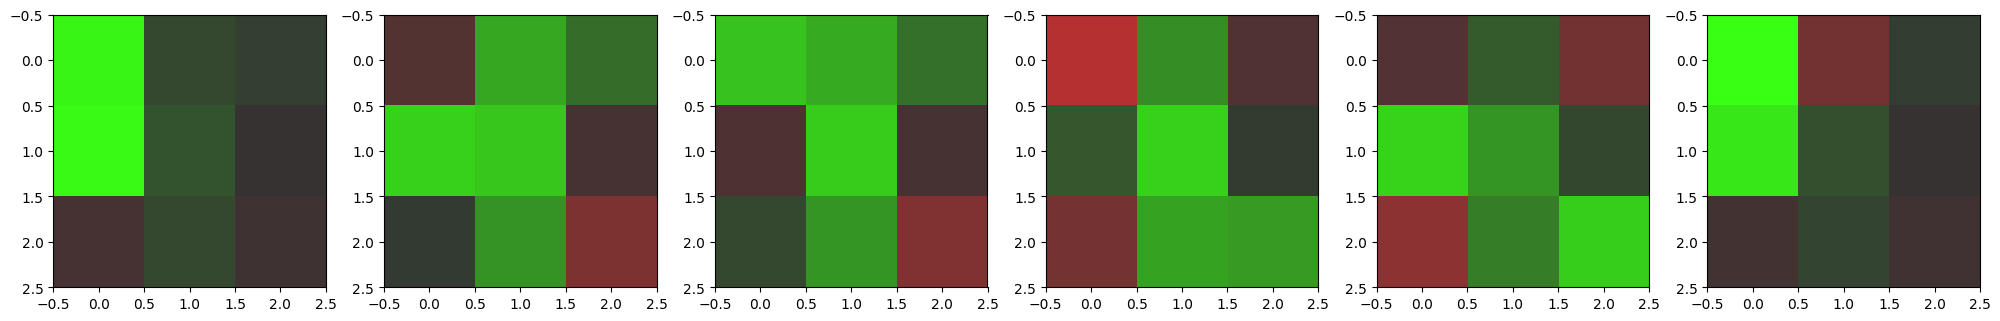

In [151]:
S([c.reshape(3,3) for c in dl.components_], 20, ncols=6)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

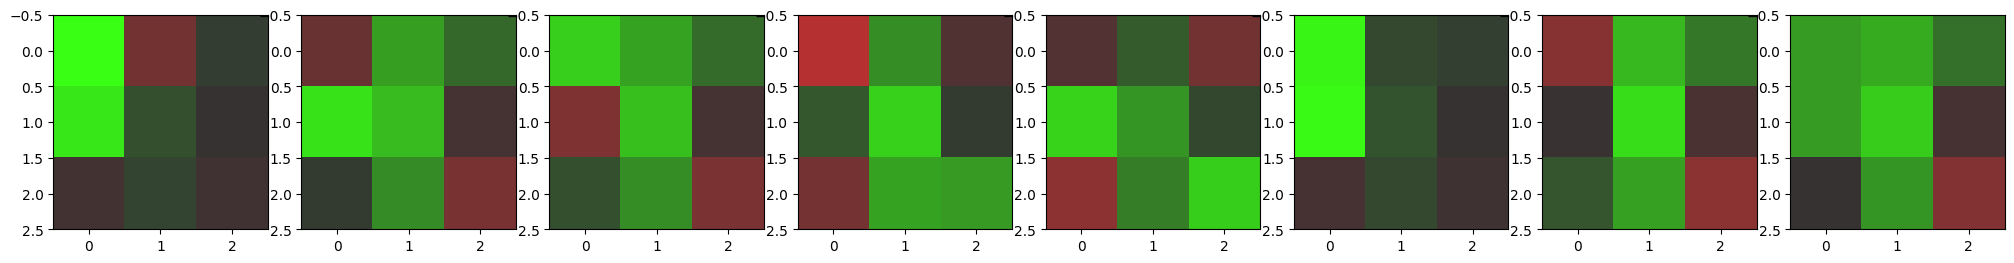

In [149]:
S([c.reshape(3,3) for c in dl.components_], 20, ncols=8)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

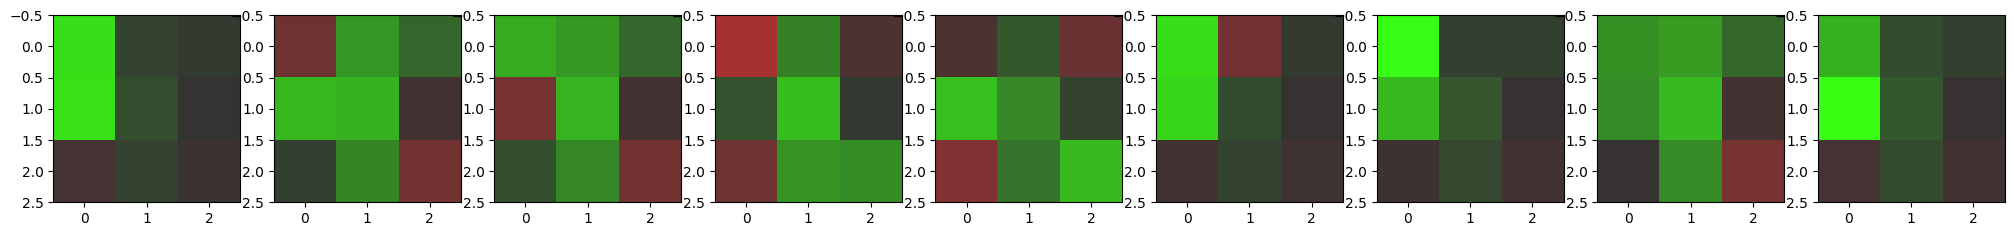

In [153]:
S([c.reshape(3,3) for c in dl.components_], 20, ncols=9)

In [88]:
model, history = train_error_model(dl, sparse_codes, X, 0.05, 1)

Epoch   50 | total=0.0302  recon=0.0285  scale=0.0017
Epoch  100 | total=0.0294  recon=0.0266  scale=0.0027
Epoch  150 | total=0.0292  recon=0.0261  scale=0.0030
Epoch  200 | total=0.0290  recon=0.0260  scale=0.0031
Epoch  250 | total=0.0290  recon=0.0258  scale=0.0031
Epoch  300 | total=0.0289  recon=0.0257  scale=0.0032
Epoch  350 | total=0.0289  recon=0.0257  scale=0.0032
Epoch  400 | total=0.0289  recon=0.0256  scale=0.0032
Epoch  450 | total=0.0289  recon=0.0256  scale=0.0032
Epoch  500 | total=0.0289  recon=0.0256  scale=0.0033


In [234]:
import numpy as np
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.optimize import linear_sum_assignment


def _do_dict_learn(inputs, n_components, **kwargs):
    X = Normalizer("max").fit_transform(inputs)
    kwargs = {
        "alpha": 1,
        "max_iter": 1000,
        **kwargs,
    }
    kwargs.pop("random_state")
    randnum = np.random.randint(0, 100)
    print("passing", randnum, kwargs)
    dl = DictionaryLearning(n_components=n_components, random_state=randnum, **kwargs)
    dl.fit(X)
    sparse_codes = dl.transform(X)
    return dl, sparse_codes, X


def _match_dictionaries(D1, D2):
    """
    Match atoms of D1 to atoms of D2 using the Hungarian algorithm
    on cosine distances. Returns (row_ind, col_ind, mean_cosine_similarity).
    
    D1, D2: shape (n_components, n_features) — sklearn's components_ layout.
    """
    # Cosine distance matrix: shape (n_components, n_components)
    cost = cosine_distances(D1, D2)          # values in [0, 2]
    row_ind, col_ind = linear_sum_assignment(cost)

    # Convert matched distances → similarities
    matched_similarities = 1 - cost[row_ind, col_ind]   # cosine similarity
    mean_sim = matched_similarities.mean()
    return row_ind, col_ind, matched_similarities, mean_sim


def dict_learn_with_stability(inputs, n_components, n_runs=10, seeds=None, **kwargs):
    """
    Run dictionary learning n_runs times and compute a seed-stability score.

    Stability score per run-pair: mean cosine similarity of optimally matched atoms.
    Global stability score: mean over all pairwise comparisons.

    Returns
    -------
    best_dl        : DictionaryLearning — the run whose dictionary is most
                     stable (highest mean pairwise similarity to all others)
    best_codes     : sparse codes from the best run
    X              : normalised input (same for all runs)
    stability_score: float in [-1, 1], higher = more stable across seeds
    run_results    : list of (dl, sparse_codes) for every run
    pairwise_sims  : (n_runs, n_runs) matrix of mean pairwise cosine similarities
    """
    if seeds is None:
        seeds = list(range(n_runs))
    assert len(seeds) == n_runs

    # ── Run dictionary learning for each seed ──────────────────────────────
    run_results = []
    X = None
    for seed in seeds:
        dl, codes, X = _do_dict_learn(inputs, n_components, random_state=seed, **kwargs)
        run_results.append((dl, codes))

    # return run_results
    # ── Pairwise stability via Hungarian matching ───────────────────────────
    pairwise_sims = np.ones((n_runs, n_runs))   # diagonal = 1 by definition

    for i in range(n_runs):
        D_i = run_results[i][0].components_     # (n_components, n_features)
        for j in range(i + 1, n_runs):
            D_j = run_results[j][0].components_
            _, _, _, mean_sim = _match_dictionaries(D_i, D_j)
            pairwise_sims[i, j] = mean_sim
            pairwise_sims[j, i] = mean_sim      # symmetric

    # ── Global stability score ──────────────────────────────────────────────
    # Average over the upper triangle (all unique pairs)
    upper = pairwise_sims[np.triu_indices(n_runs, k=1)]
    stability_score = upper.mean()

    # ── Best run: highest average similarity to all other runs ─────────────
    mean_sim_per_run = pairwise_sims.mean(axis=1)   # includes self=1
    best_run_idx = int(np.argmax(mean_sim_per_run))
    best_dl, best_codes = run_results[best_run_idx]

    print(f"Stability score : {stability_score:.4f}  (1.0 = perfectly stable)")
    print(f"Best run        : seed={seeds[best_run_idx]}  "
          f"(mean sim to others = {mean_sim_per_run[best_run_idx]:.4f})")

    return best_dl, best_codes, X, stability_score, run_results, pairwise_sims

In [235]:
res= dict_learn_with_stability(
    pw,
    n_components=15,
    n_runs=10,          # how many seeds to try
    # seeds=[0,1,...,9] # or supply your own
)

passing 56 {'alpha': 1, 'max_iter': 1000}
passing 41 {'alpha': 1, 'max_iter': 1000}
passing 69 {'alpha': 1, 'max_iter': 1000}
passing 71 {'alpha': 1, 'max_iter': 1000}
passing 22 {'alpha': 1, 'max_iter': 1000}
passing 20 {'alpha': 1, 'max_iter': 1000}
passing 1 {'alpha': 1, 'max_iter': 1000}
passing 40 {'alpha': 1, 'max_iter': 1000}
passing 25 {'alpha': 1, 'max_iter': 1000}
passing 92 {'alpha': 1, 'max_iter': 1000}
Stability score : 0.9733  (1.0 = perfectly stable)
Best run        : seed=5  (mean sim to others = 0.9847)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

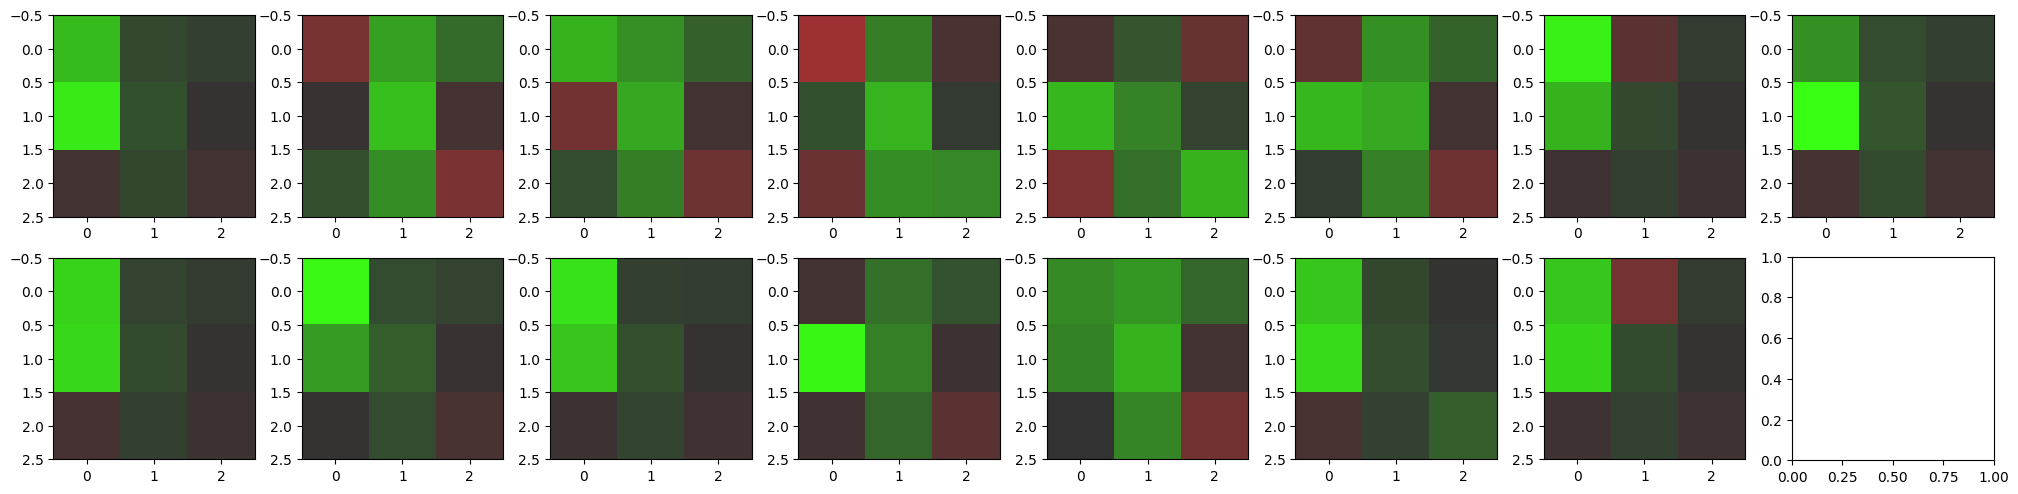

In [231]:
S([c.reshape(3,3) for c in res[0][0].components_], (20, 5), ncols=8)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

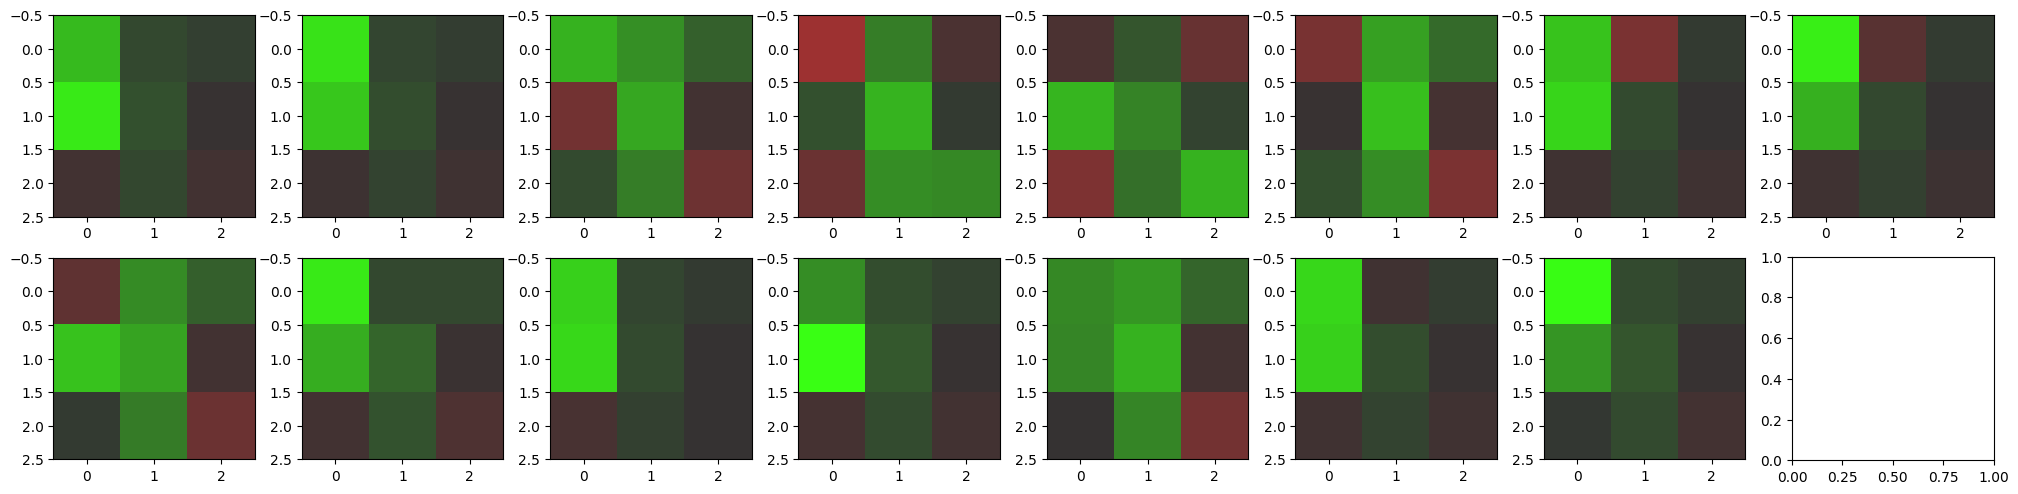

In [233]:
S([c.reshape(3,3) for c in res[1][0].components_], (20, 5), ncols=8)

In [160]:
best_dl, best_codes, X, score, all_runs, sim_matrix = dict_learn_with_stability(
    pw,
    n_components=5,
    n_runs=10,          # how many seeds to try
    # seeds=[0,1,...,9] # or supply your own
)

Stability score : 1.0000  (1.0 = perfectly stable)
Best run        : seed=0  (mean sim to others = 1.0000)


In [90]:
recons = sparse_codes @ dl.components_

In [93]:
model.eval()
with torch.no_grad():
    x_hat_np   = sparse_codes @ dl.components_
    epsilon_np = X - x_hat_np

    x       = torch.tensor(X,          dtype=torch.float32)
    x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
    epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

    correction = model(epsilon)
    x_final    = x_hat + correction

    loss_base  = ((x_hat  - x) ** 2).mean(dim=1)   # (N,)
    loss_final = ((x_final - x) ** 2).mean(dim=1)  # (N,)

    scale_ratio = correction.norm(dim=1) / (x_hat.norm(dim=1) + 1e-8)

In [113]:

# x_final.shape, X.shape
scale_ratio.mean(), loss_final.mean(), loss_base.mean(), (scale_ratio / 0.01).mean()

(tensor(0.0915), tensor(0.0256), tensor(0.0355), tensor(9.1522))

In [104]:
correction.shape

torch.Size([363, 9])

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

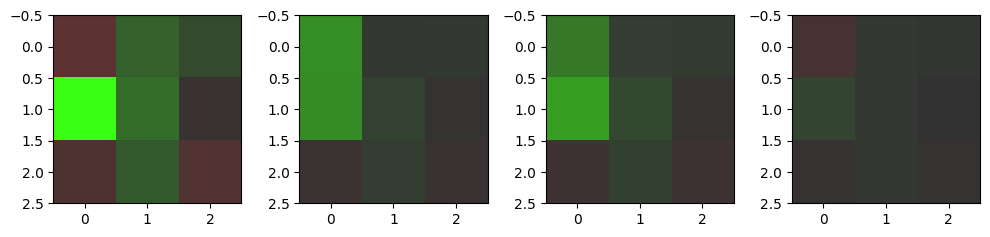

In [ ]:

S([X[0].reshape(3,3), recons[0].reshape(3,3), x_final[0].reshape(3,3), correction[0].reshape(3,3)], 10, ncols=4, viztype="global")

In [106]:
correction[0] / x_final[0]

tensor([-0.2993,  0.5142,  0.2877,  0.1705,  0.2533,  0.3150,  0.3199,  0.2615,
         0.3681])

In [101]:
epsilon[0], recons[0]

(tensor([-0.6458,  0.2001,  0.0833,  0.5626,  0.2070, -0.0285, -0.0953,  0.1340,
         -0.1164]),
 array([ 0.43886811,  0.02329493,  0.02902049,  0.43735003,  0.07663577,
        -0.00900796, -0.04185441,  0.04897561, -0.03095565]))

array([<Axes: >, <Axes: >], dtype=object)

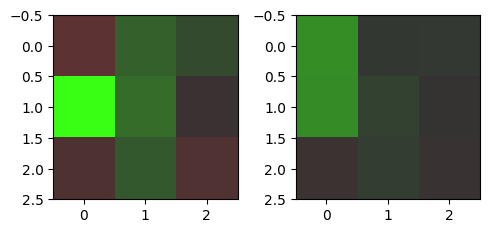

In [92]:
S([X[0].reshape(3,3), recons[0].reshape(3,3)])
# recons[0], X[0]